Skipping learning_rate_current: unexpected filename format


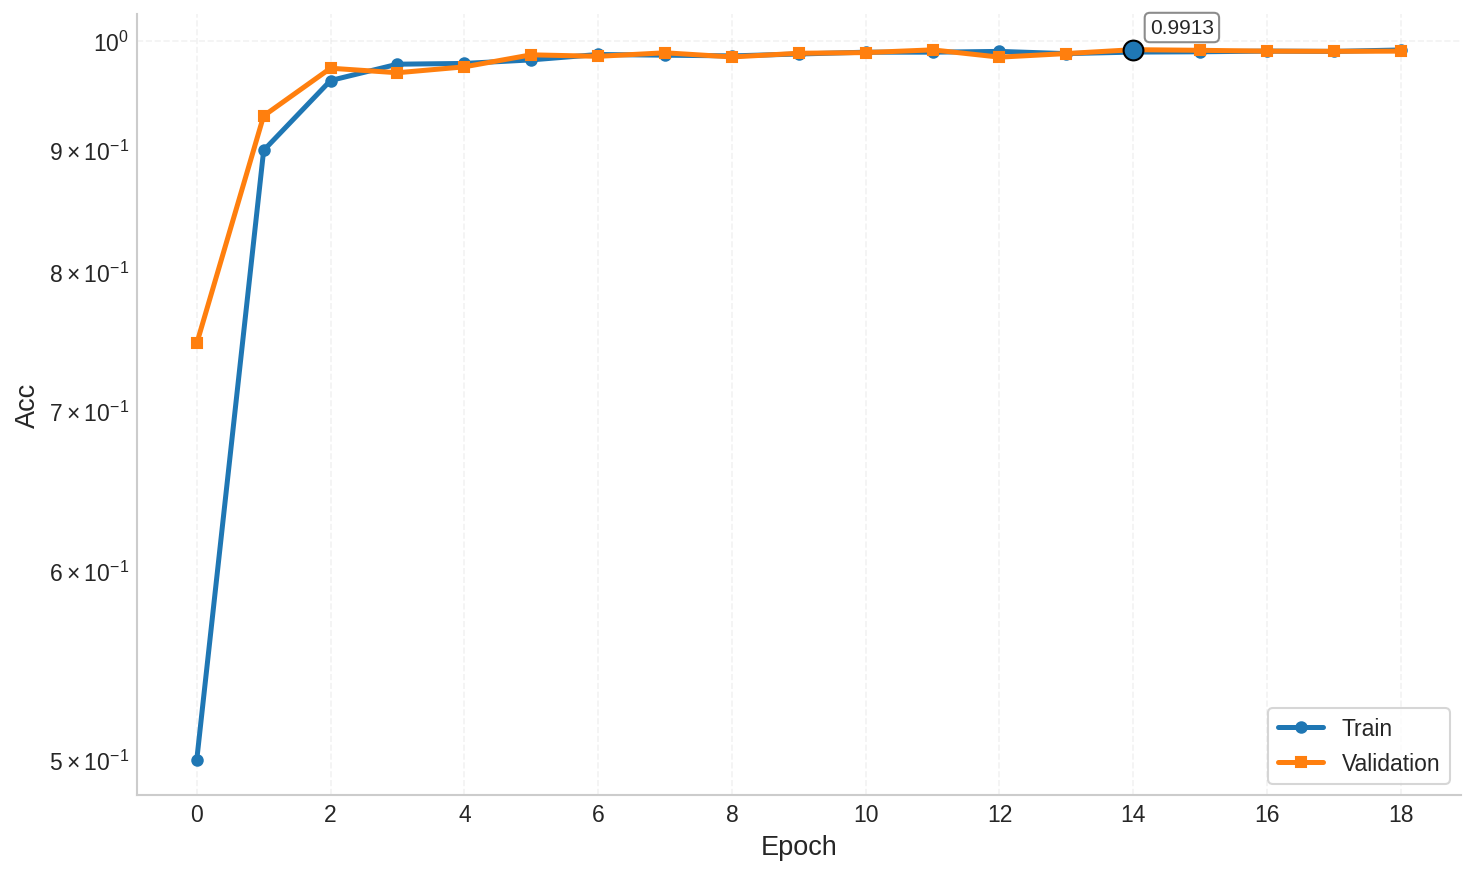

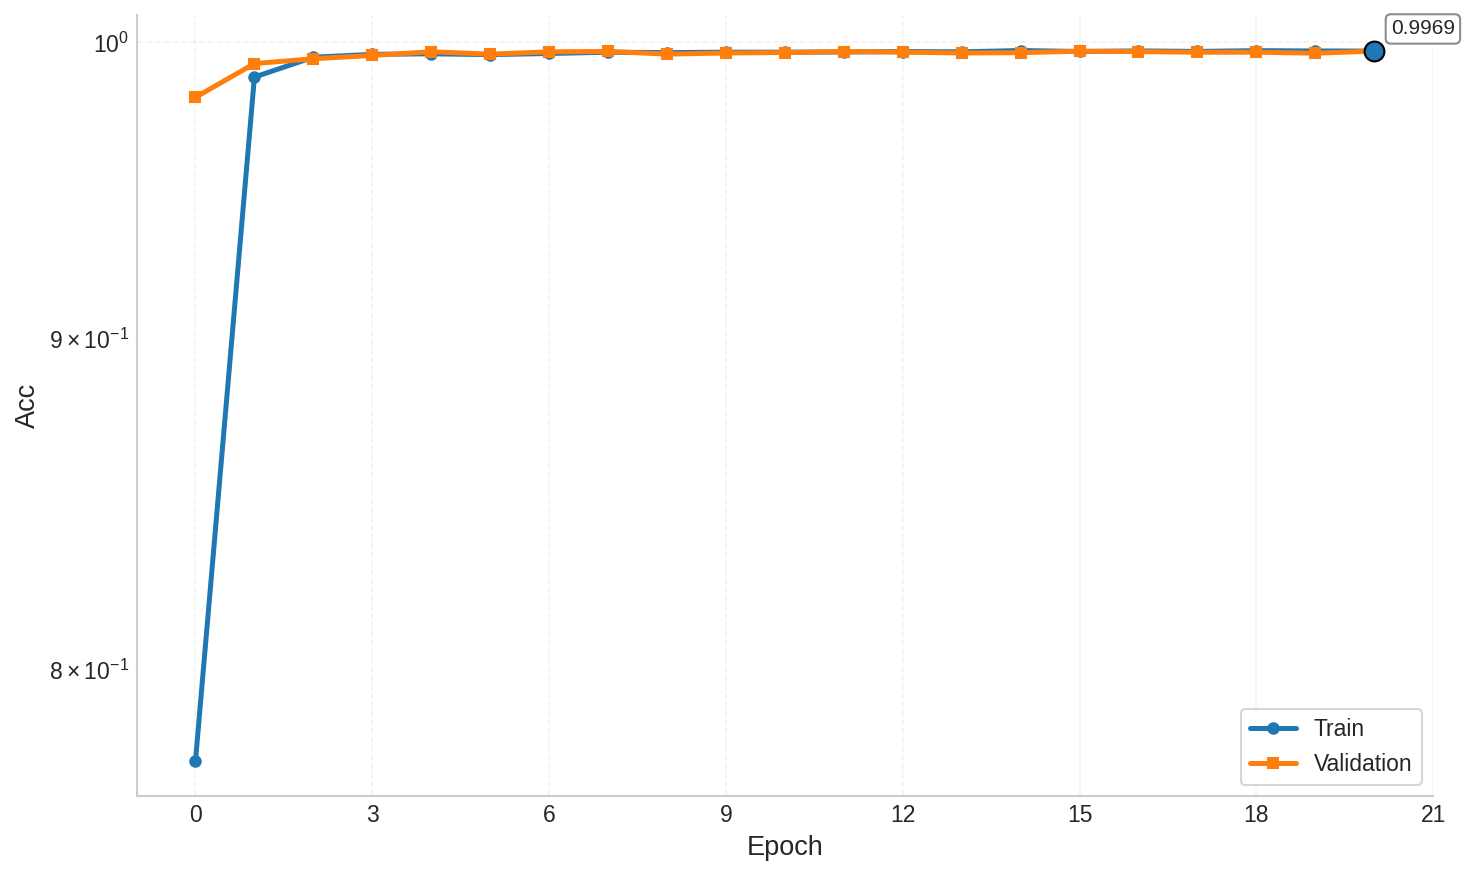

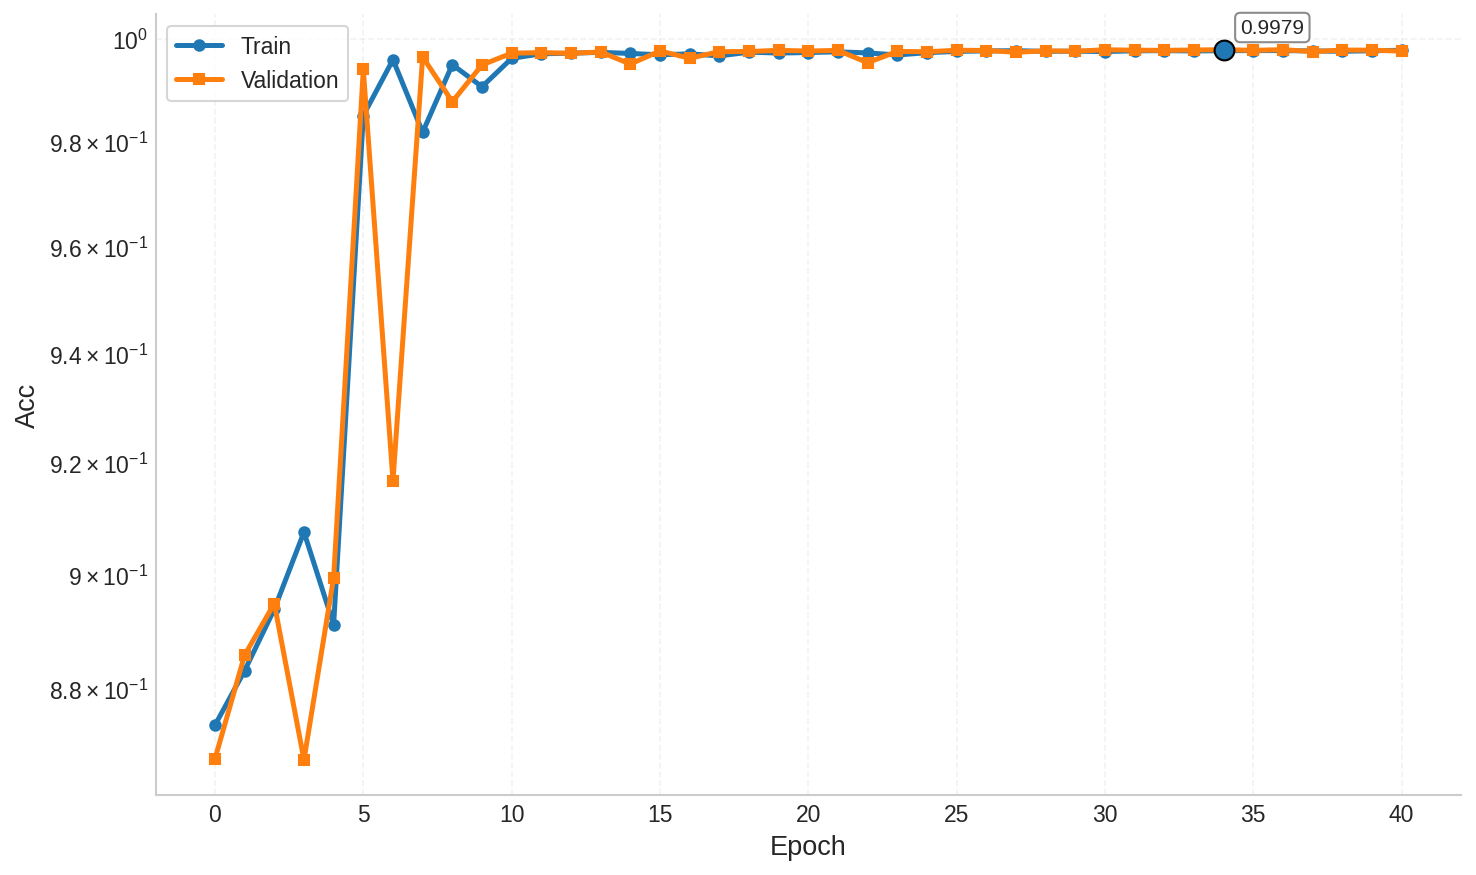

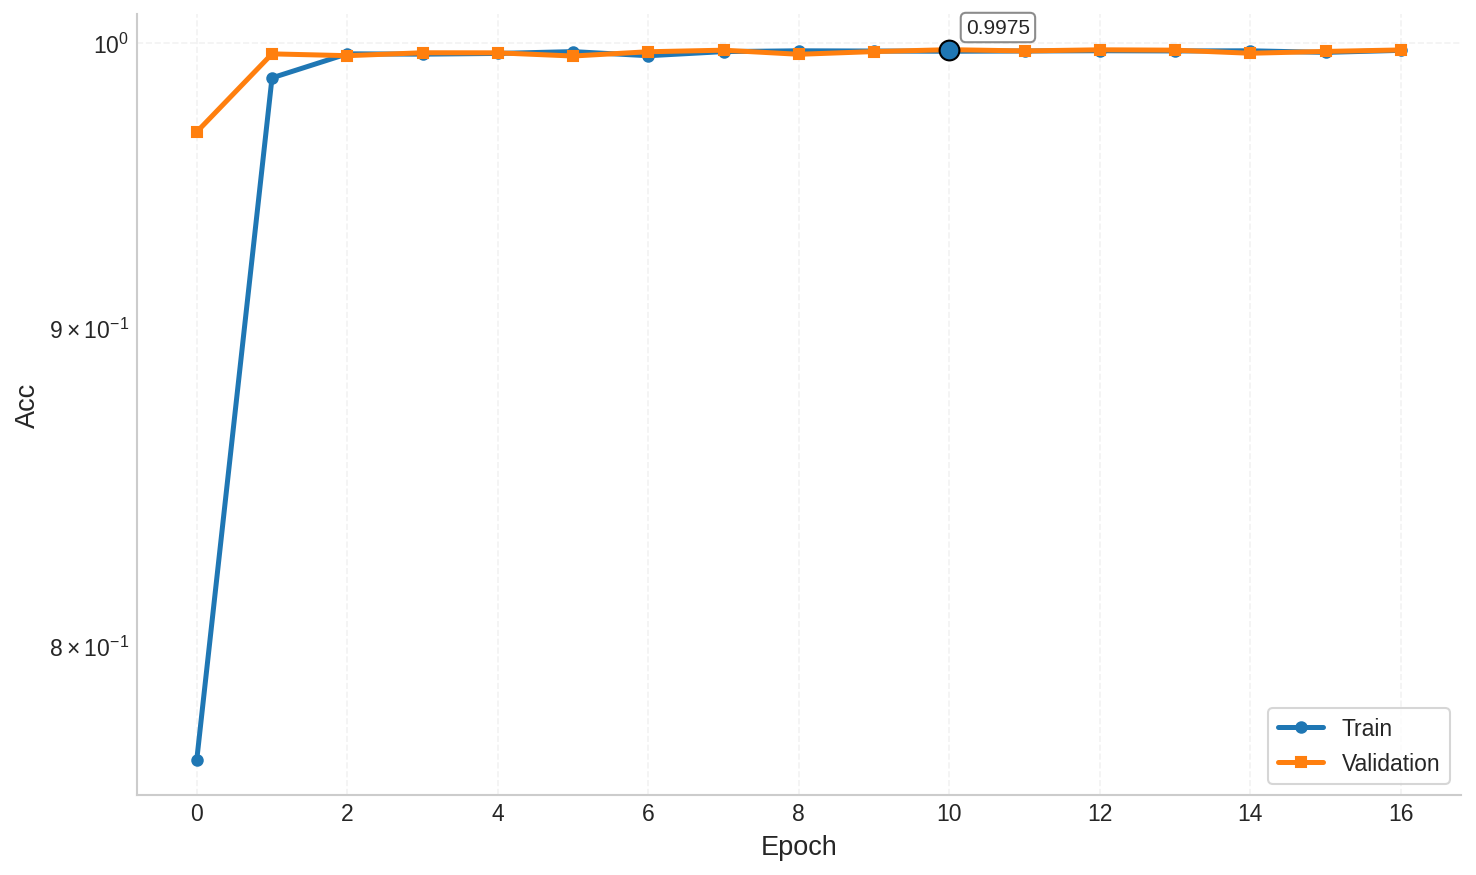

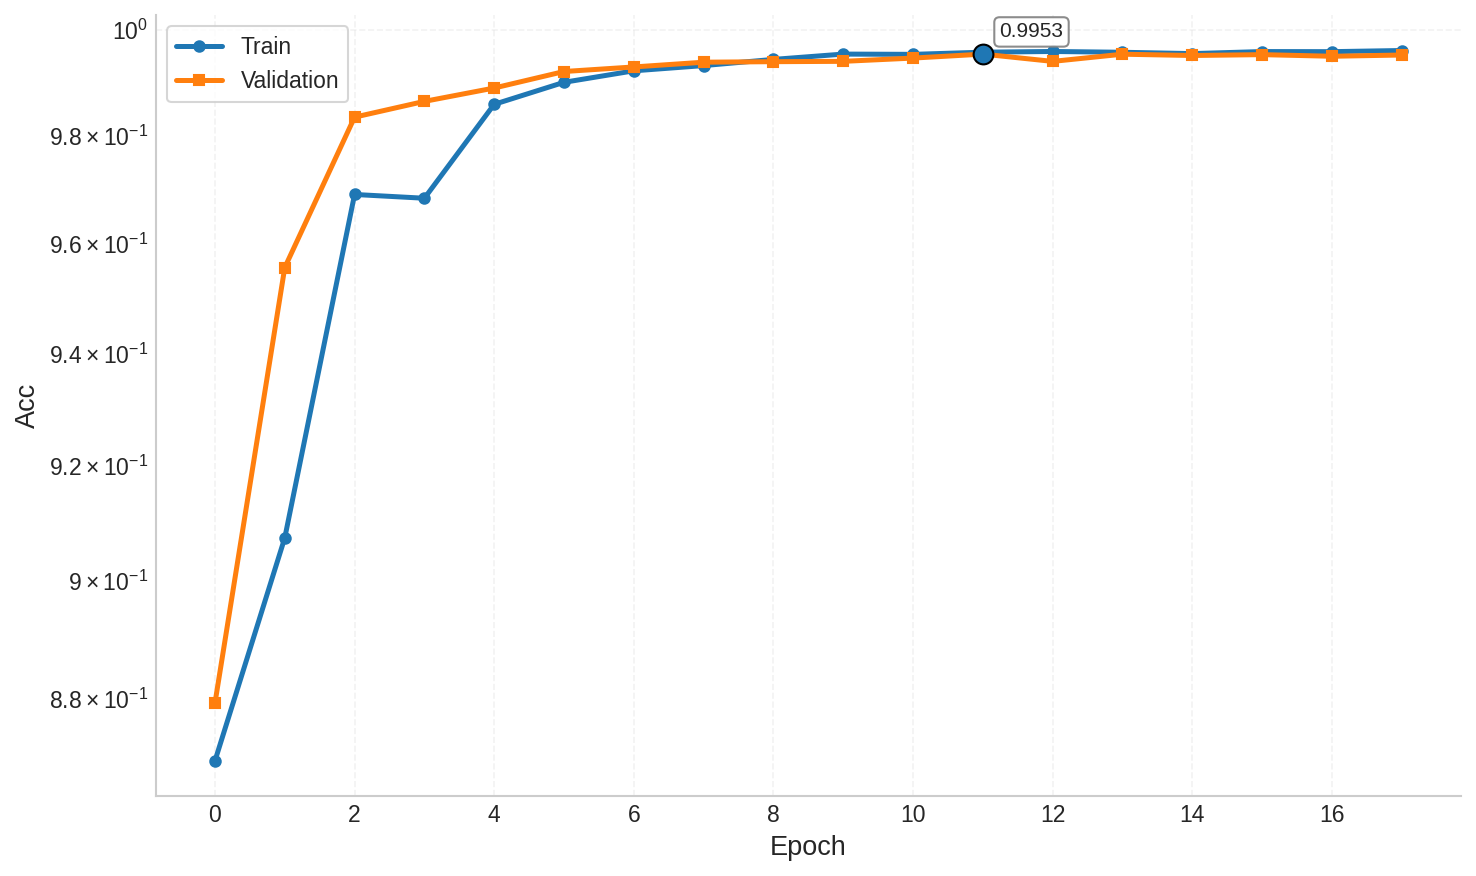

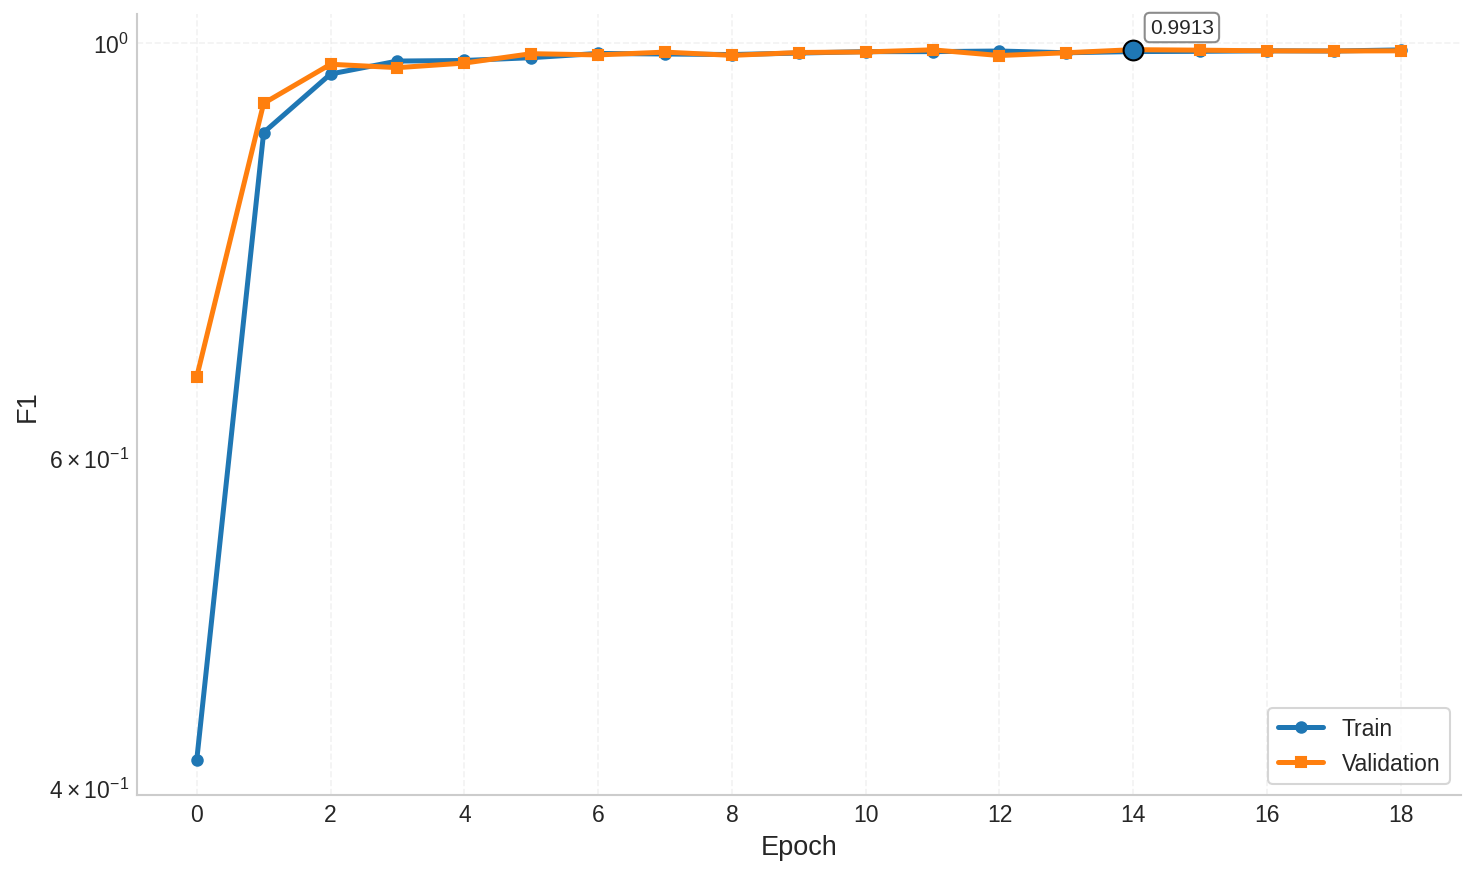

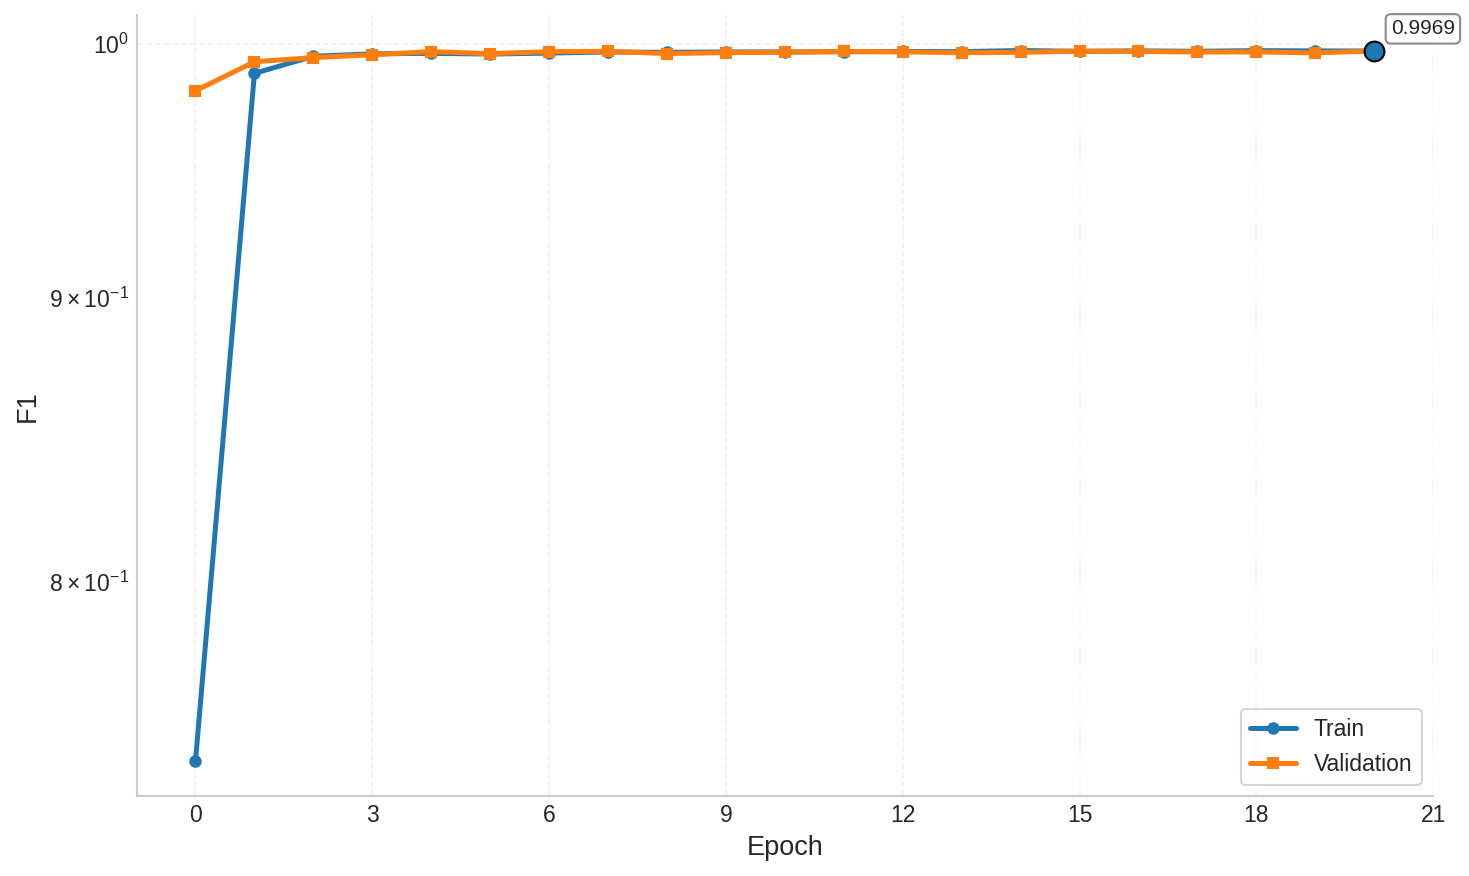

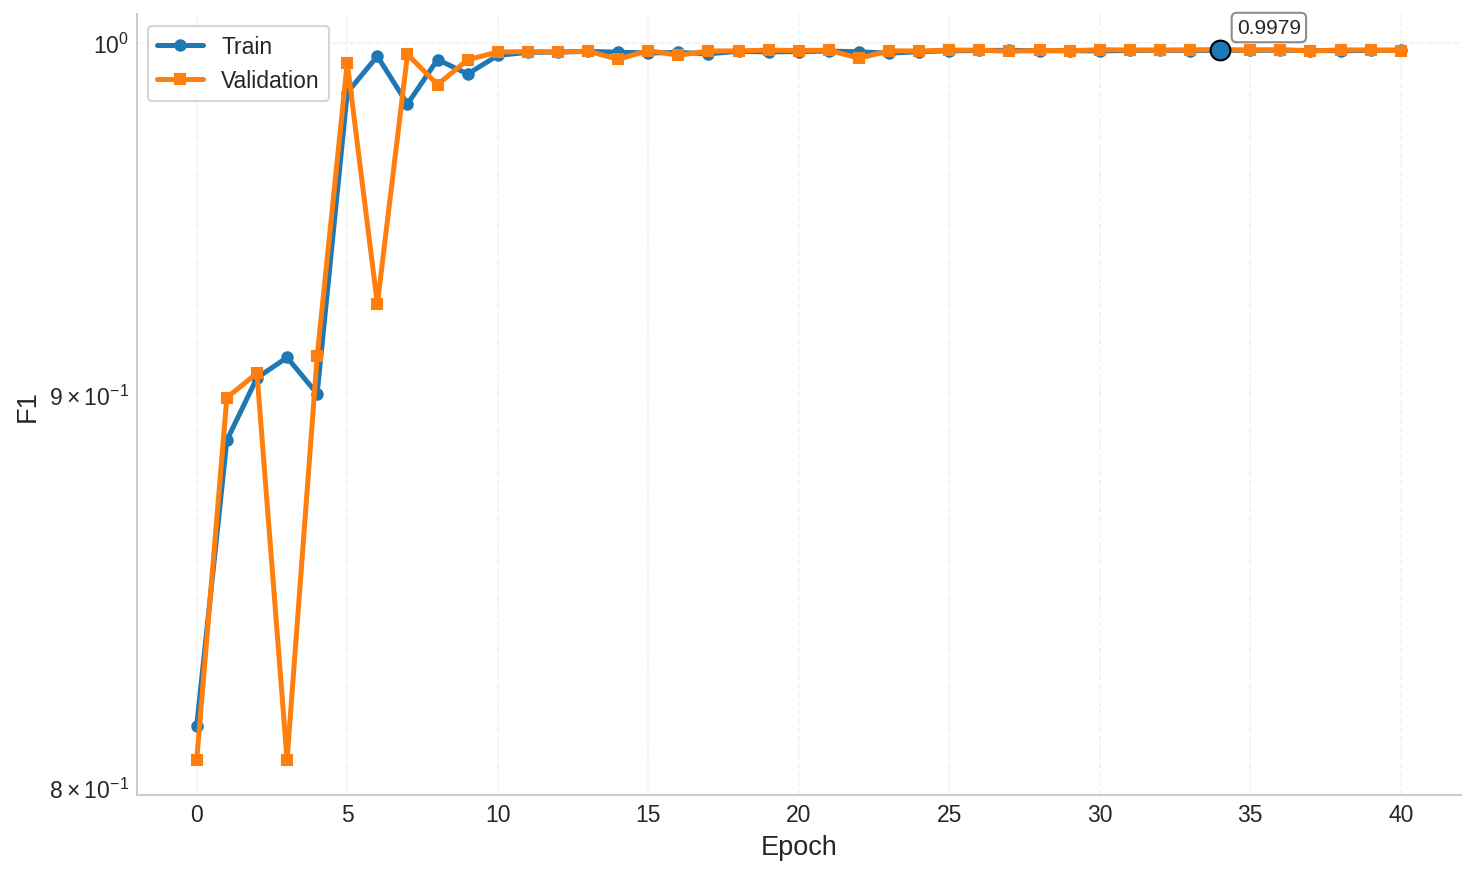

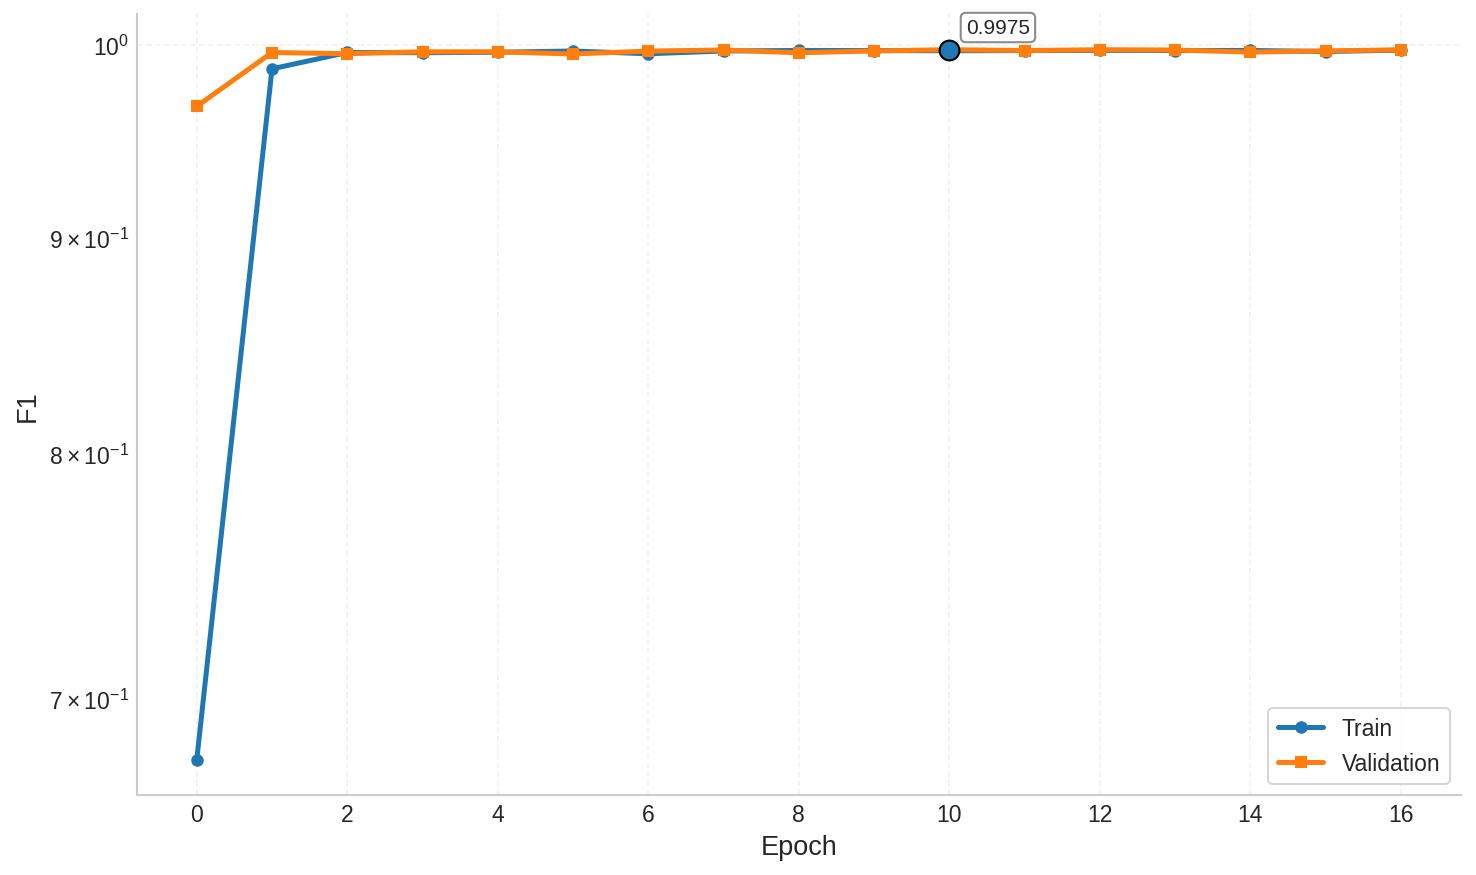

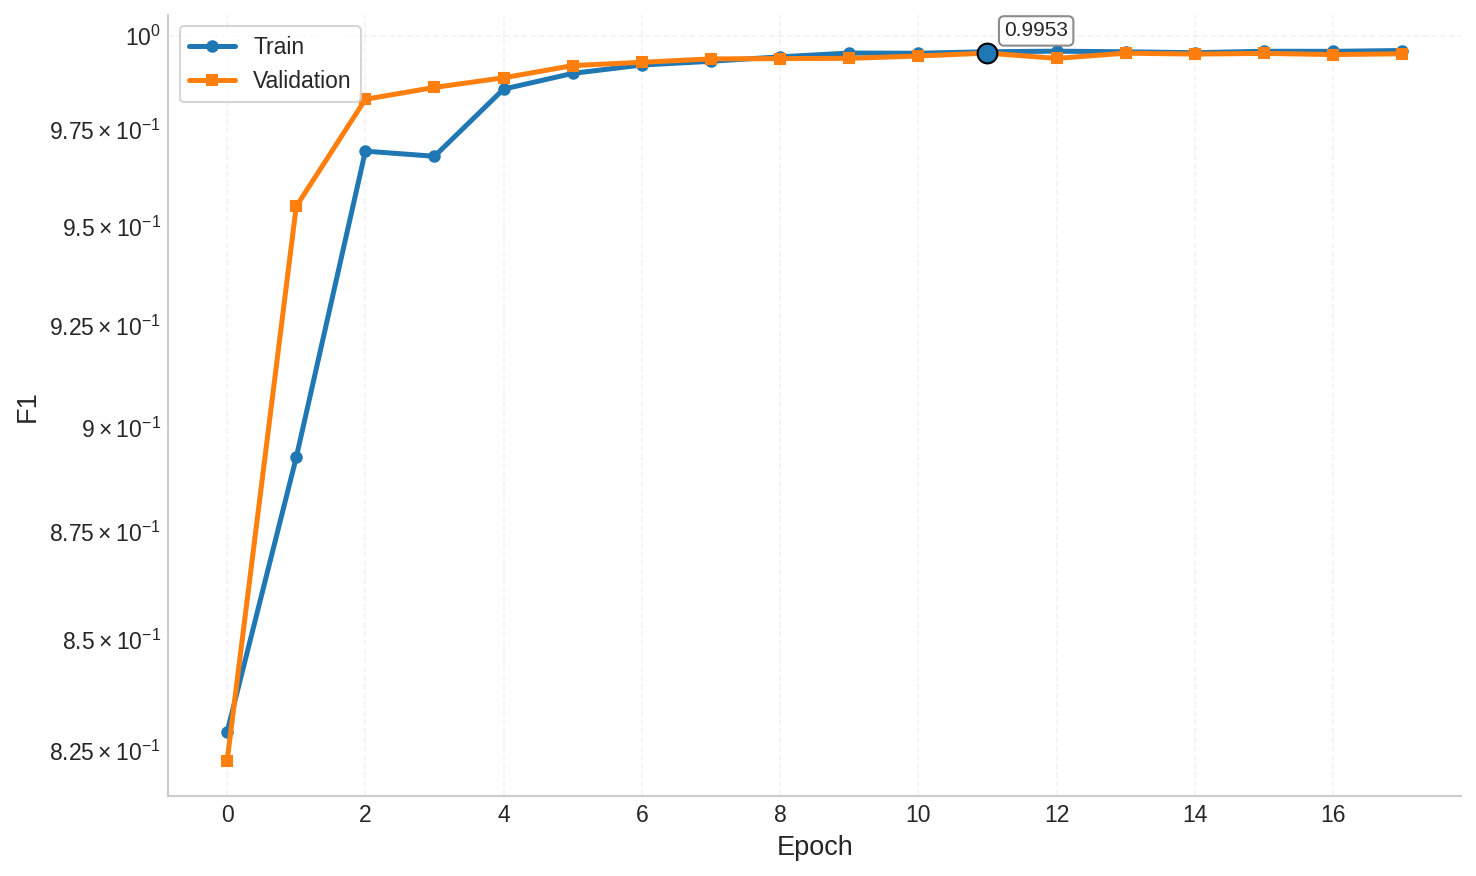

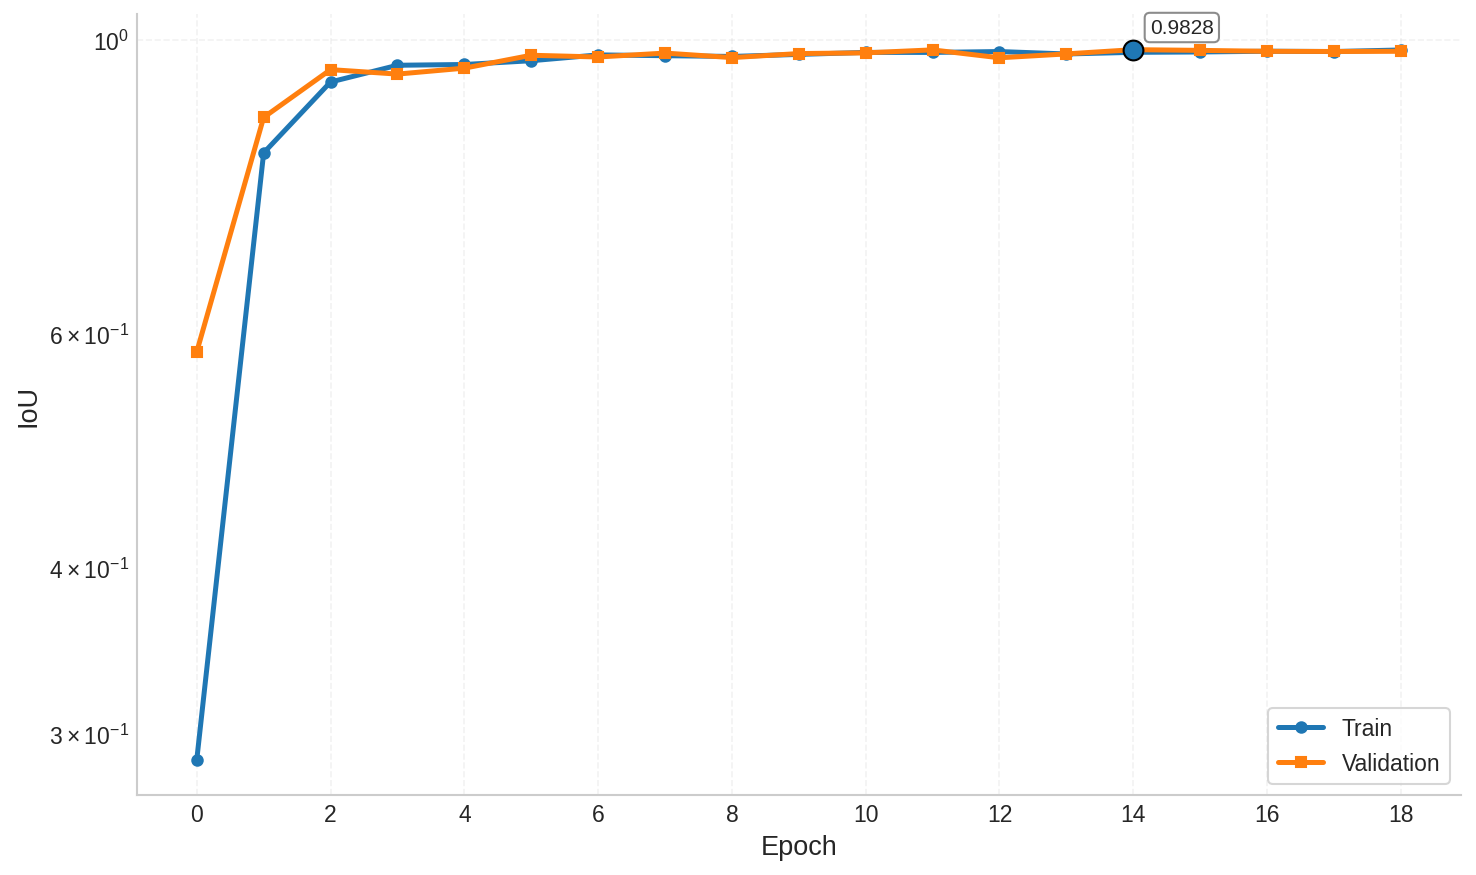

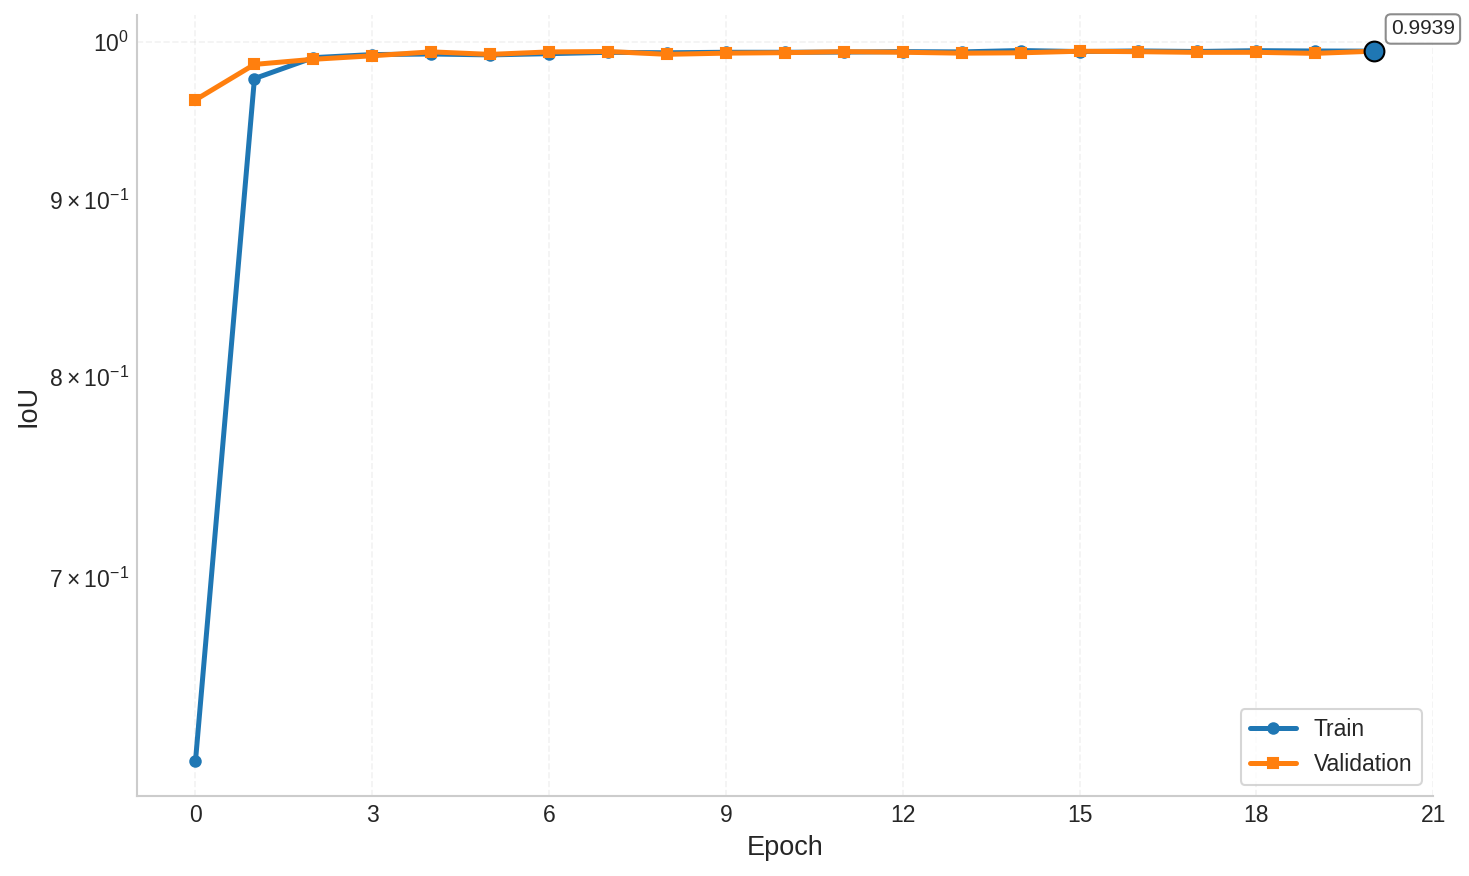

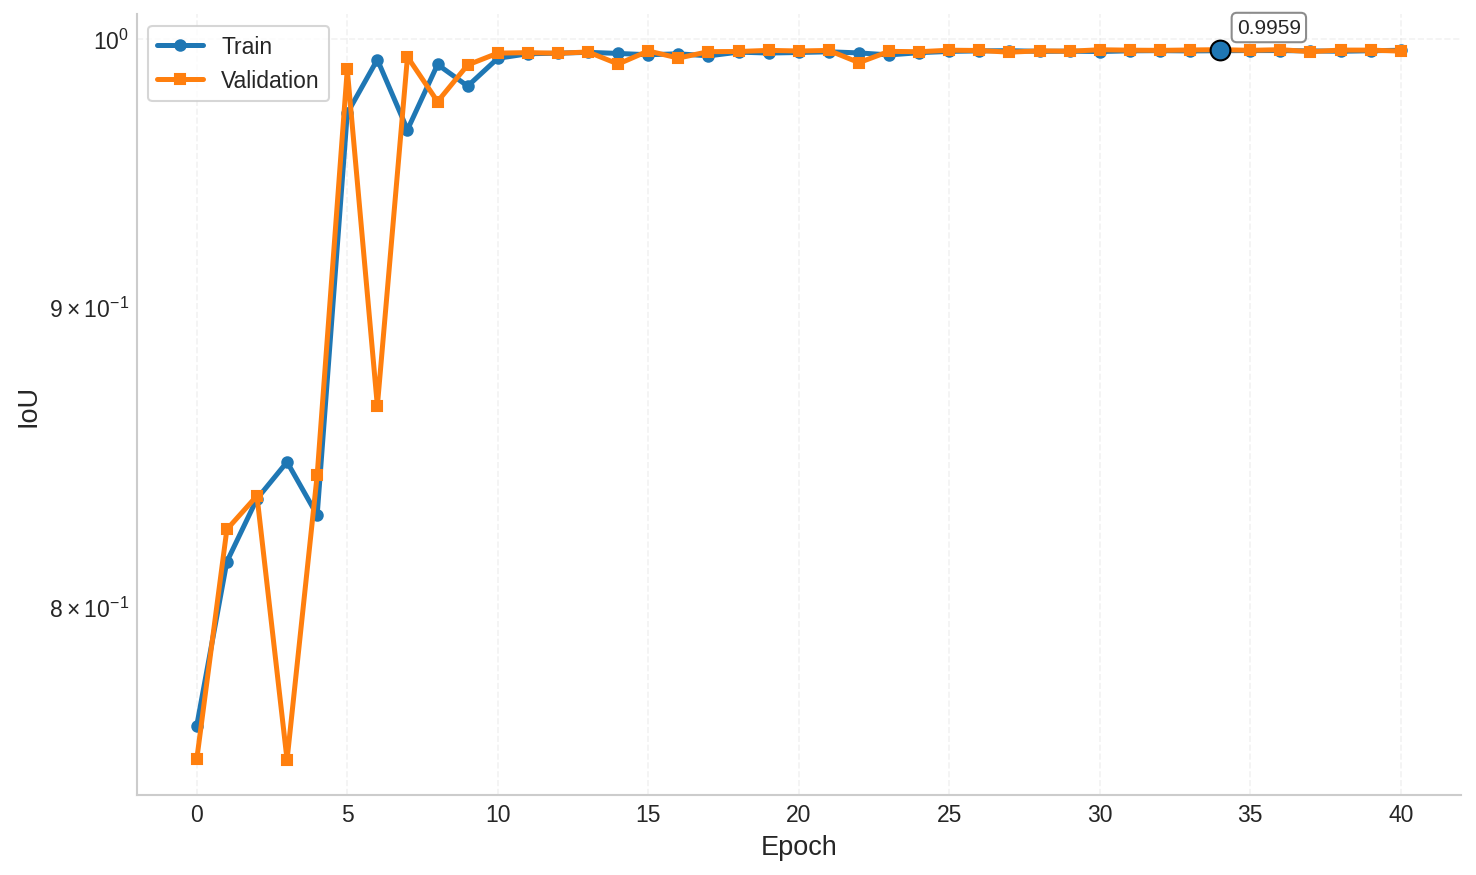

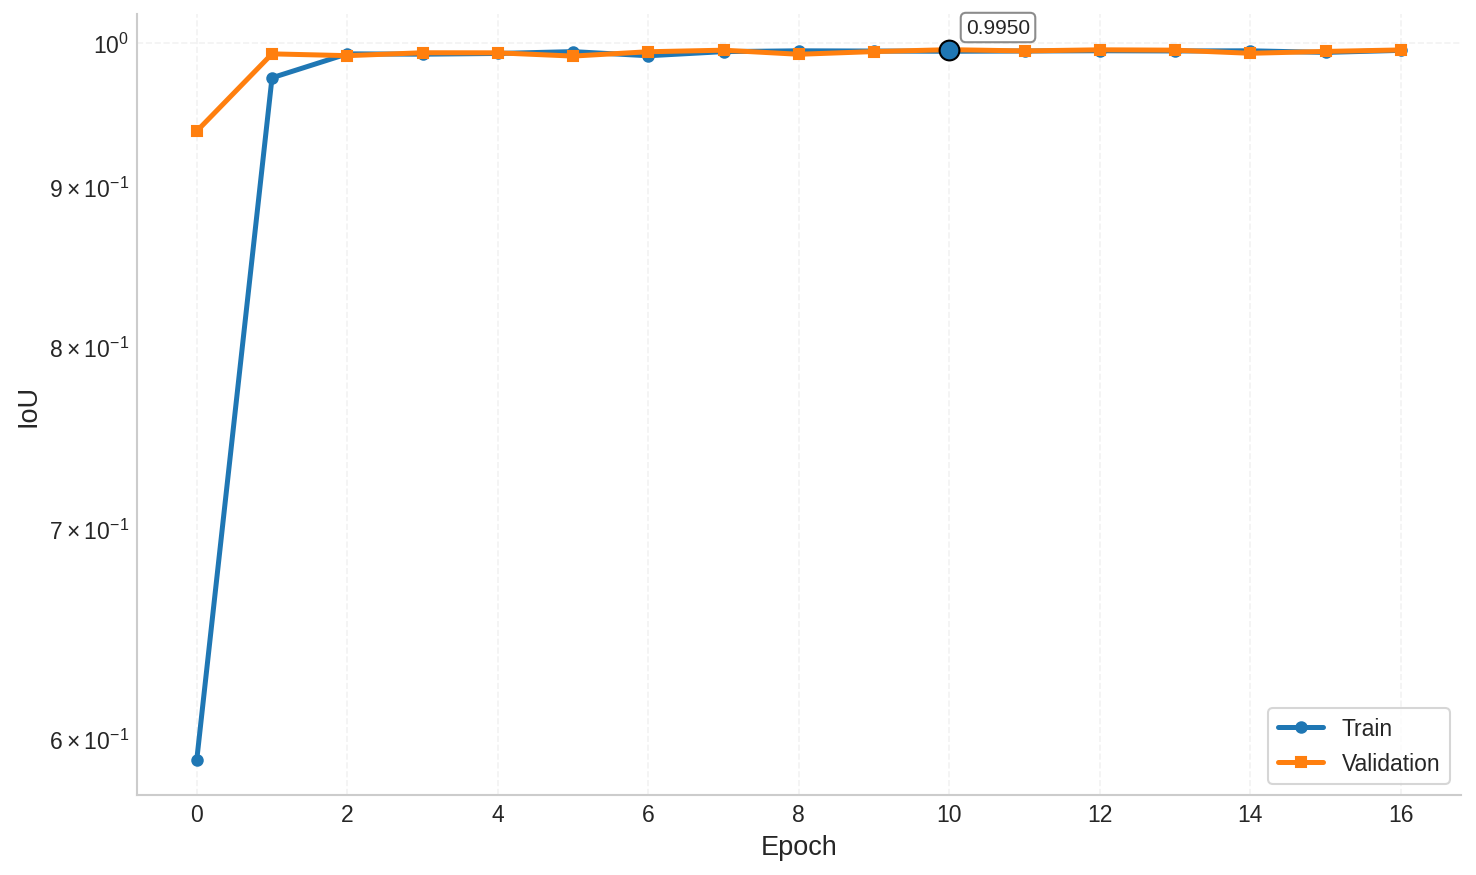

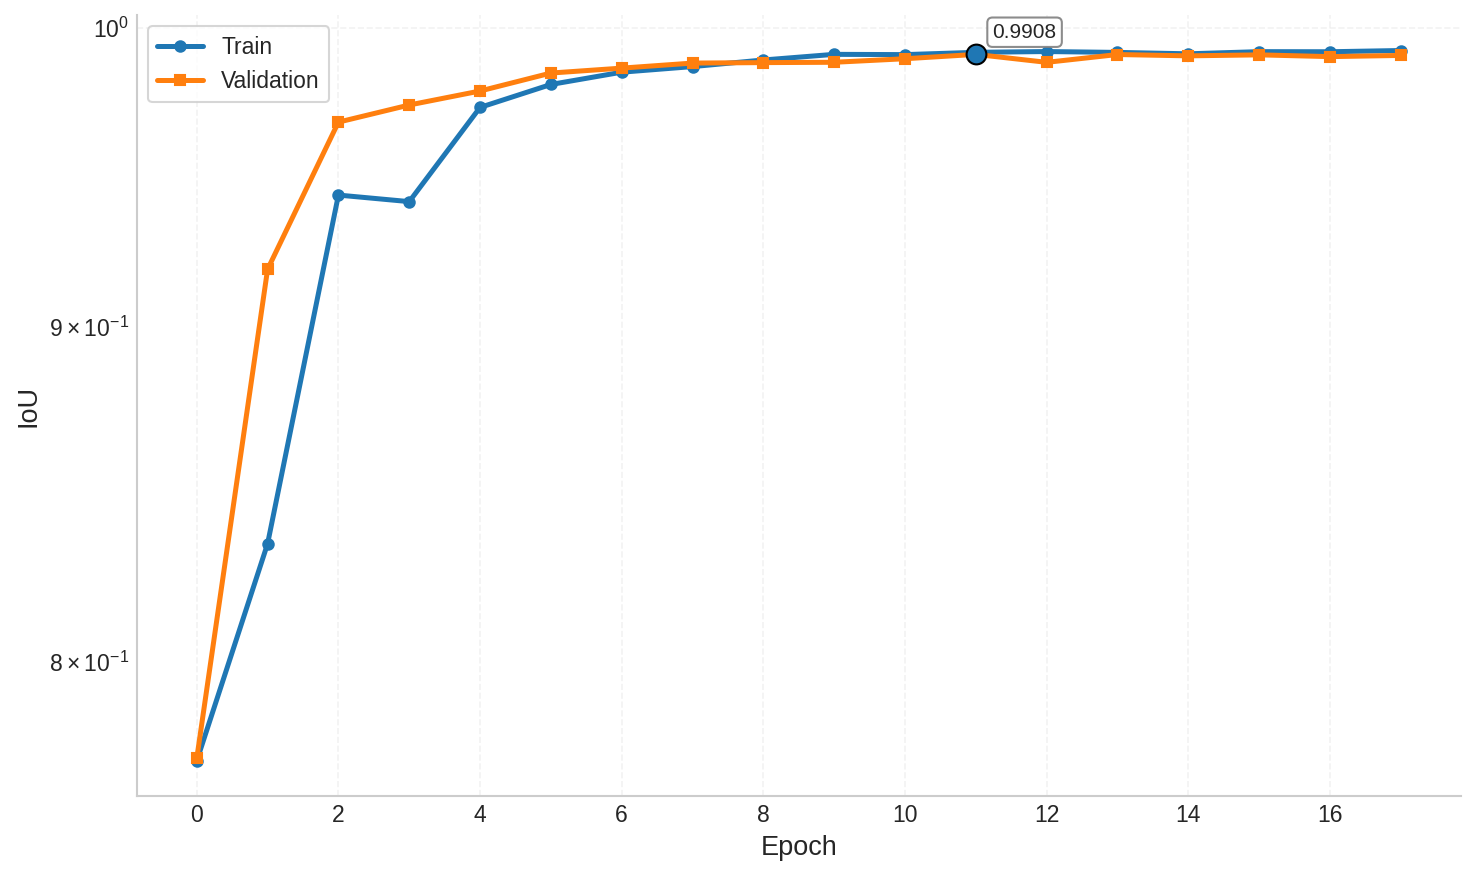

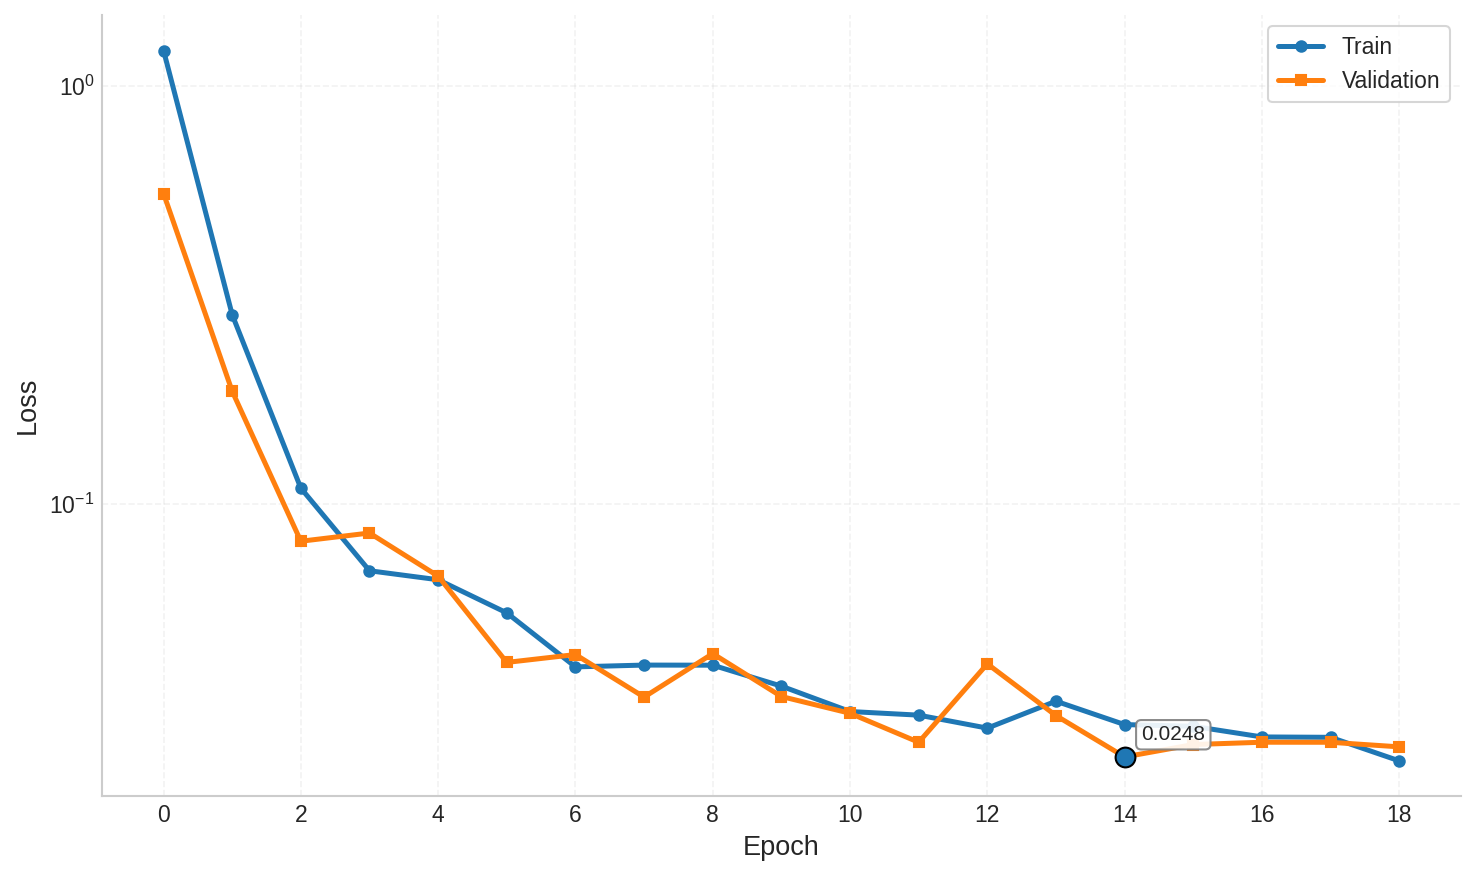

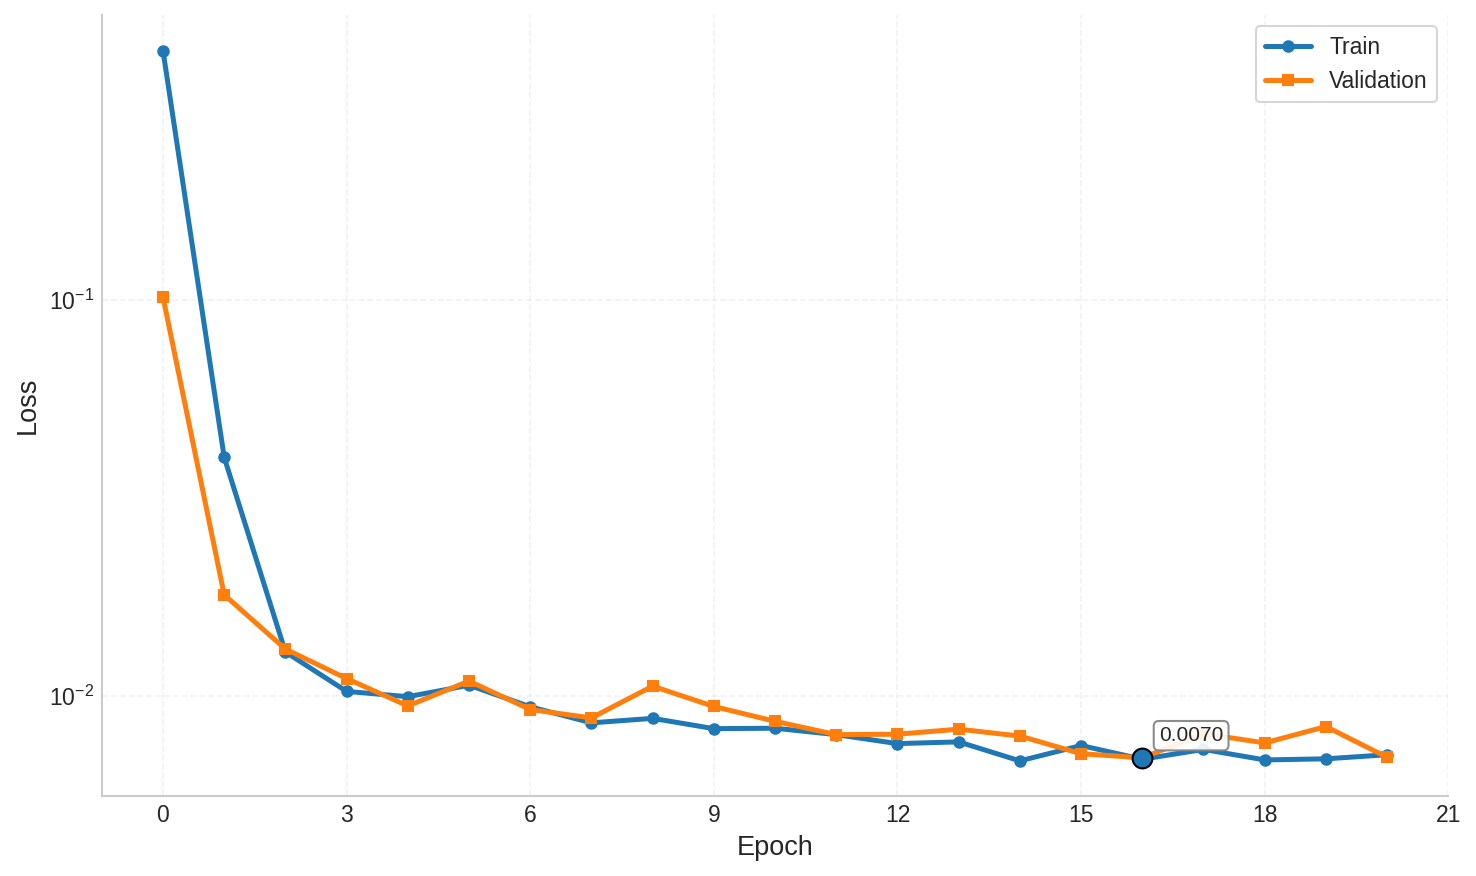

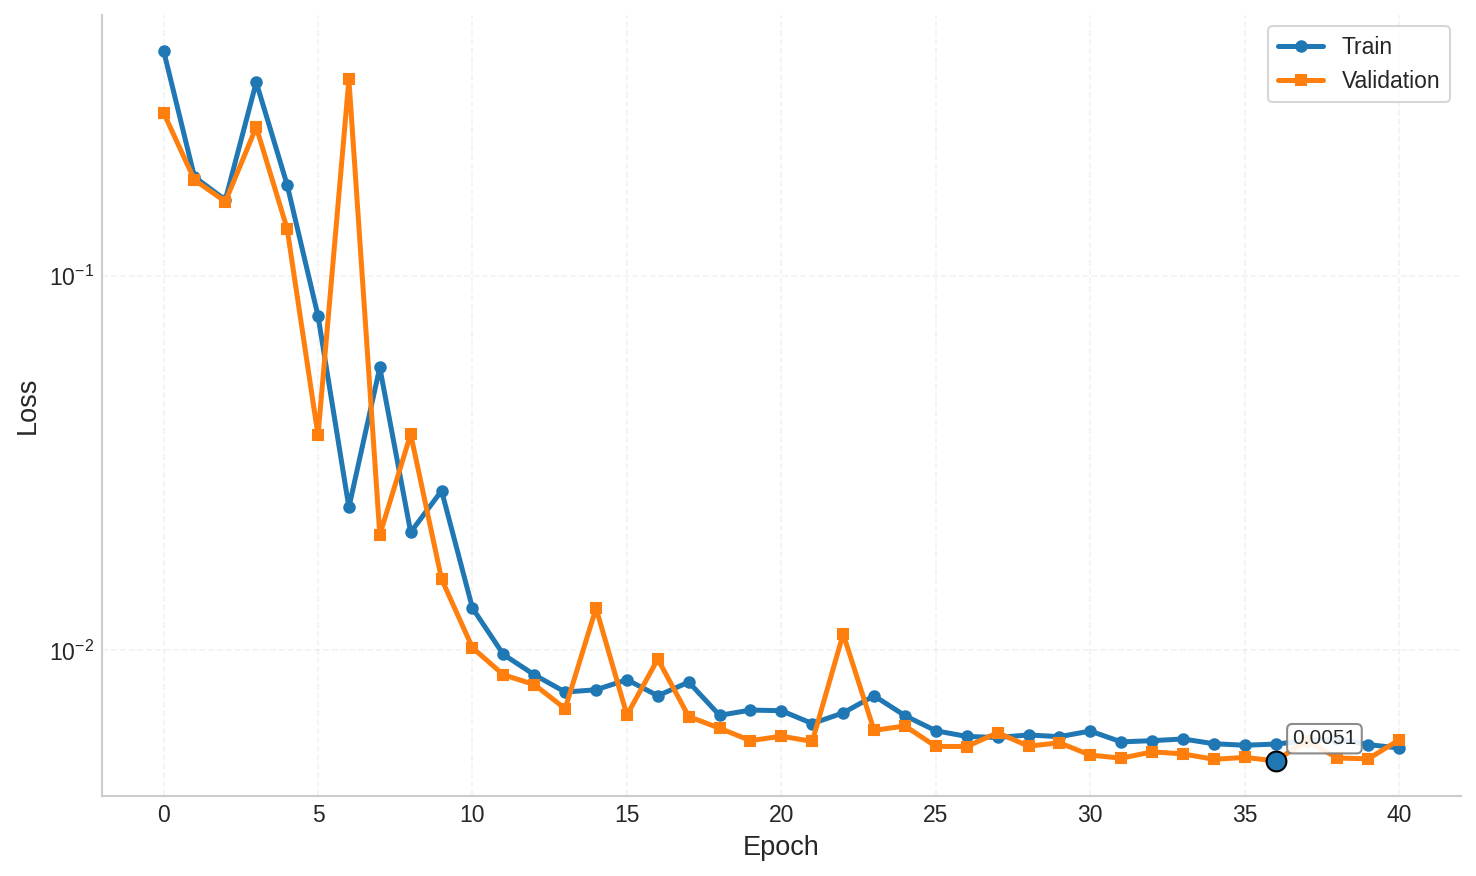

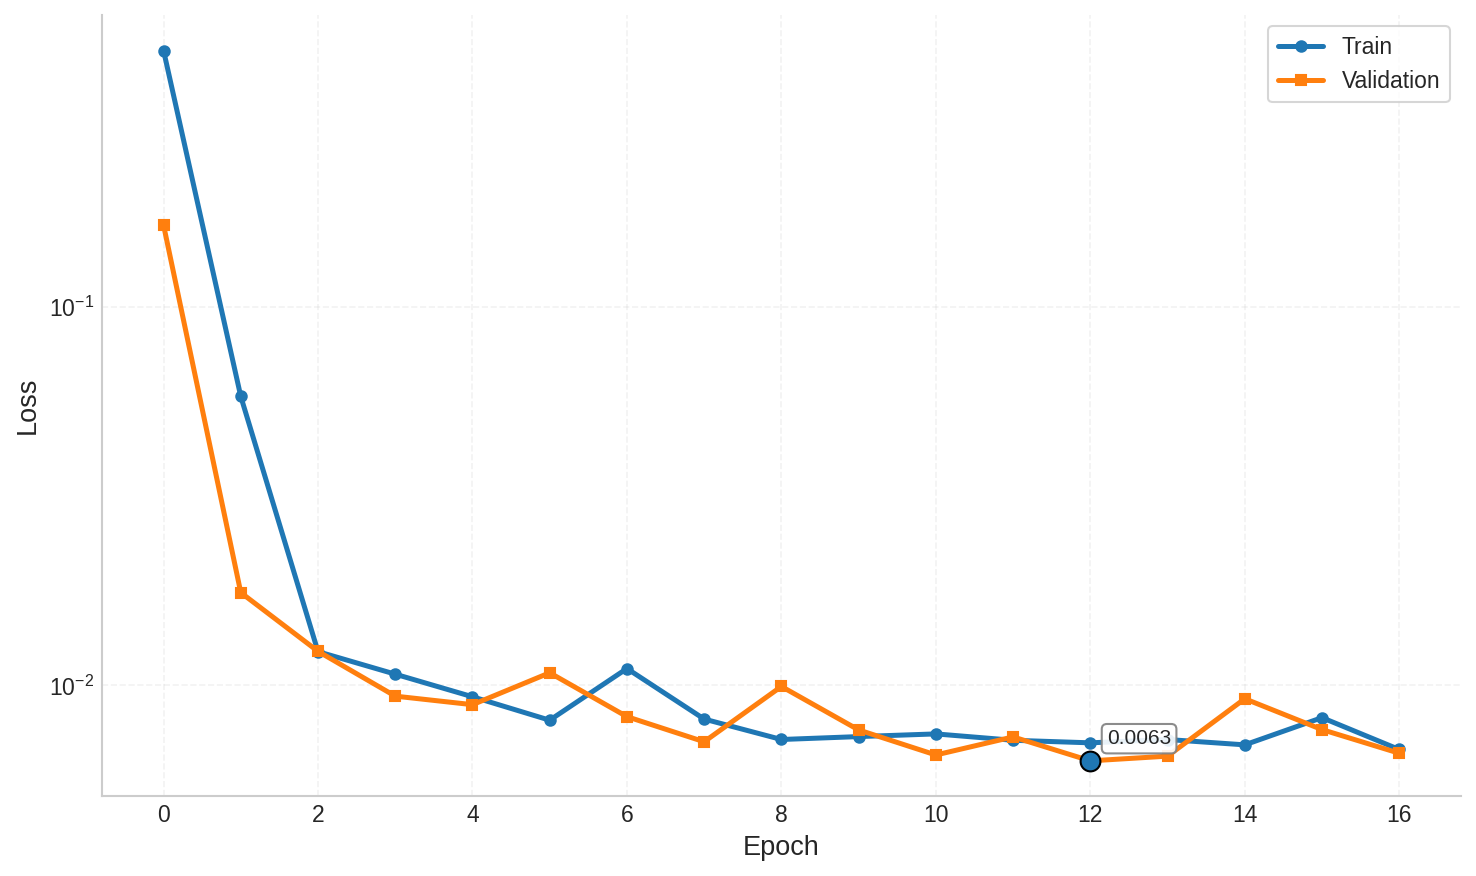

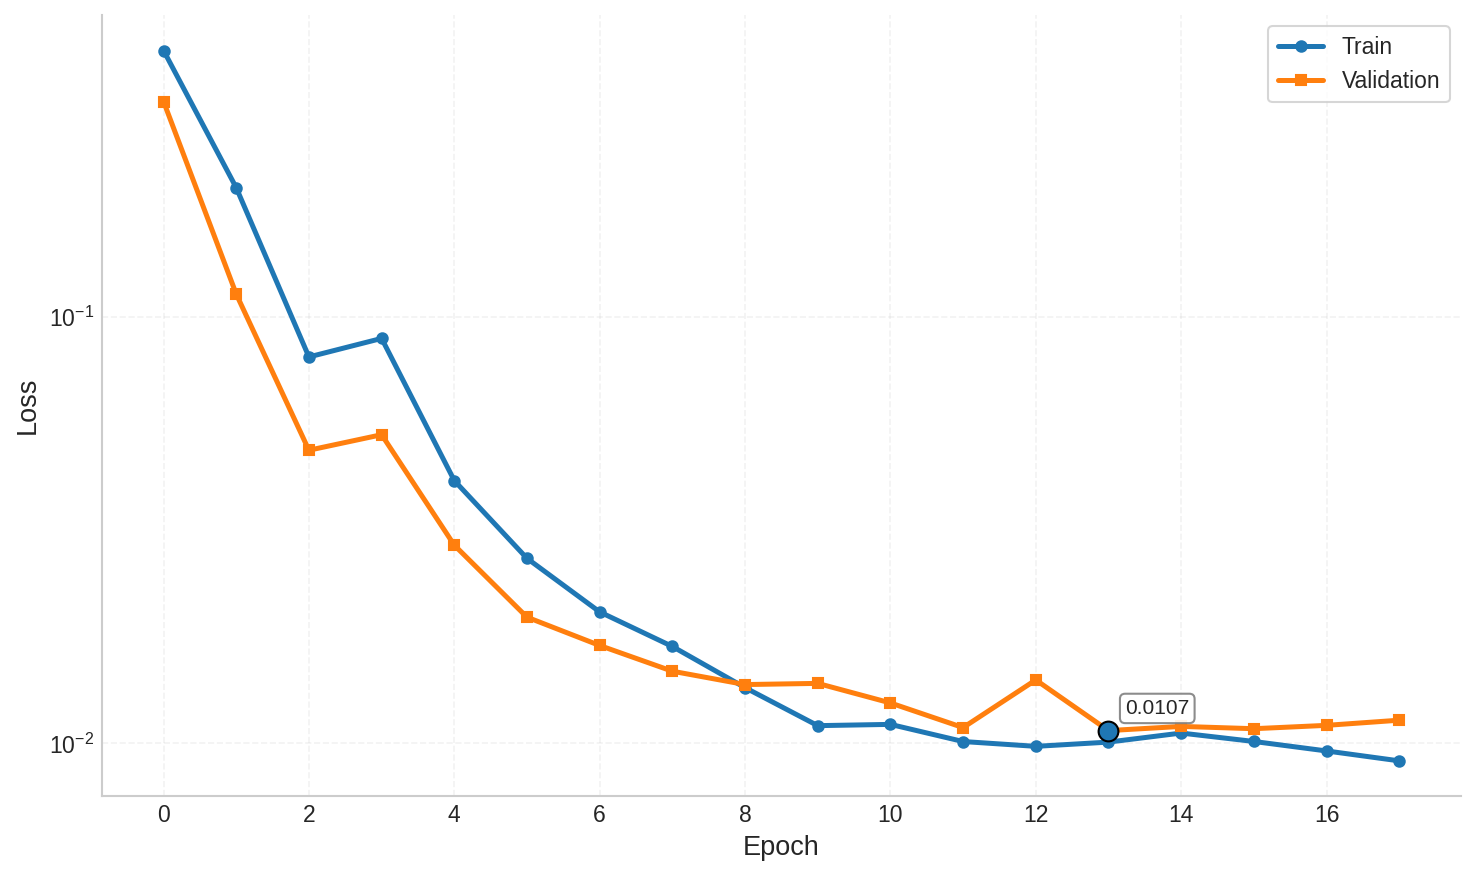

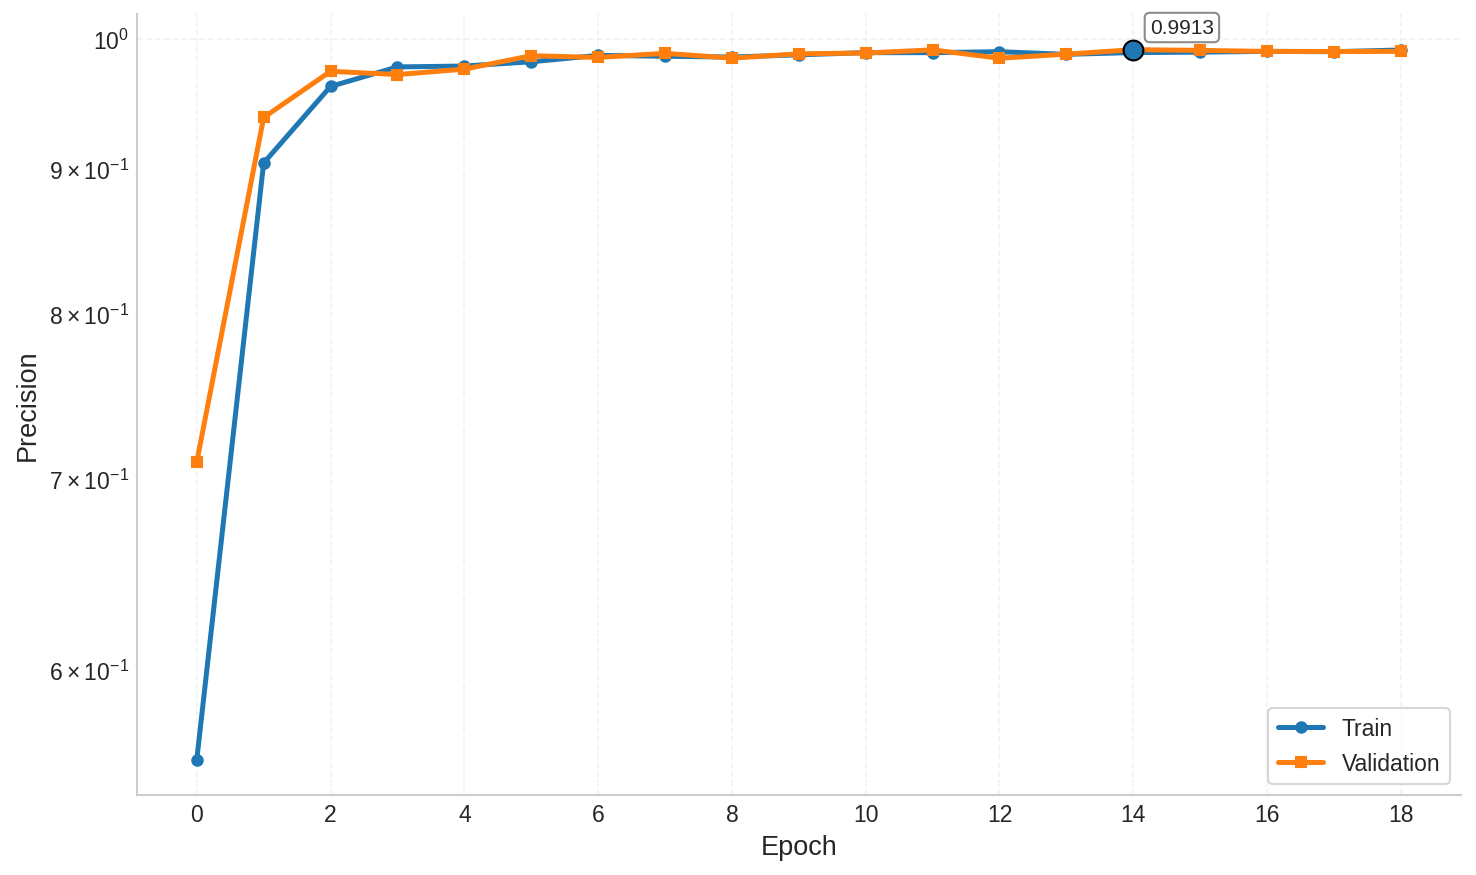

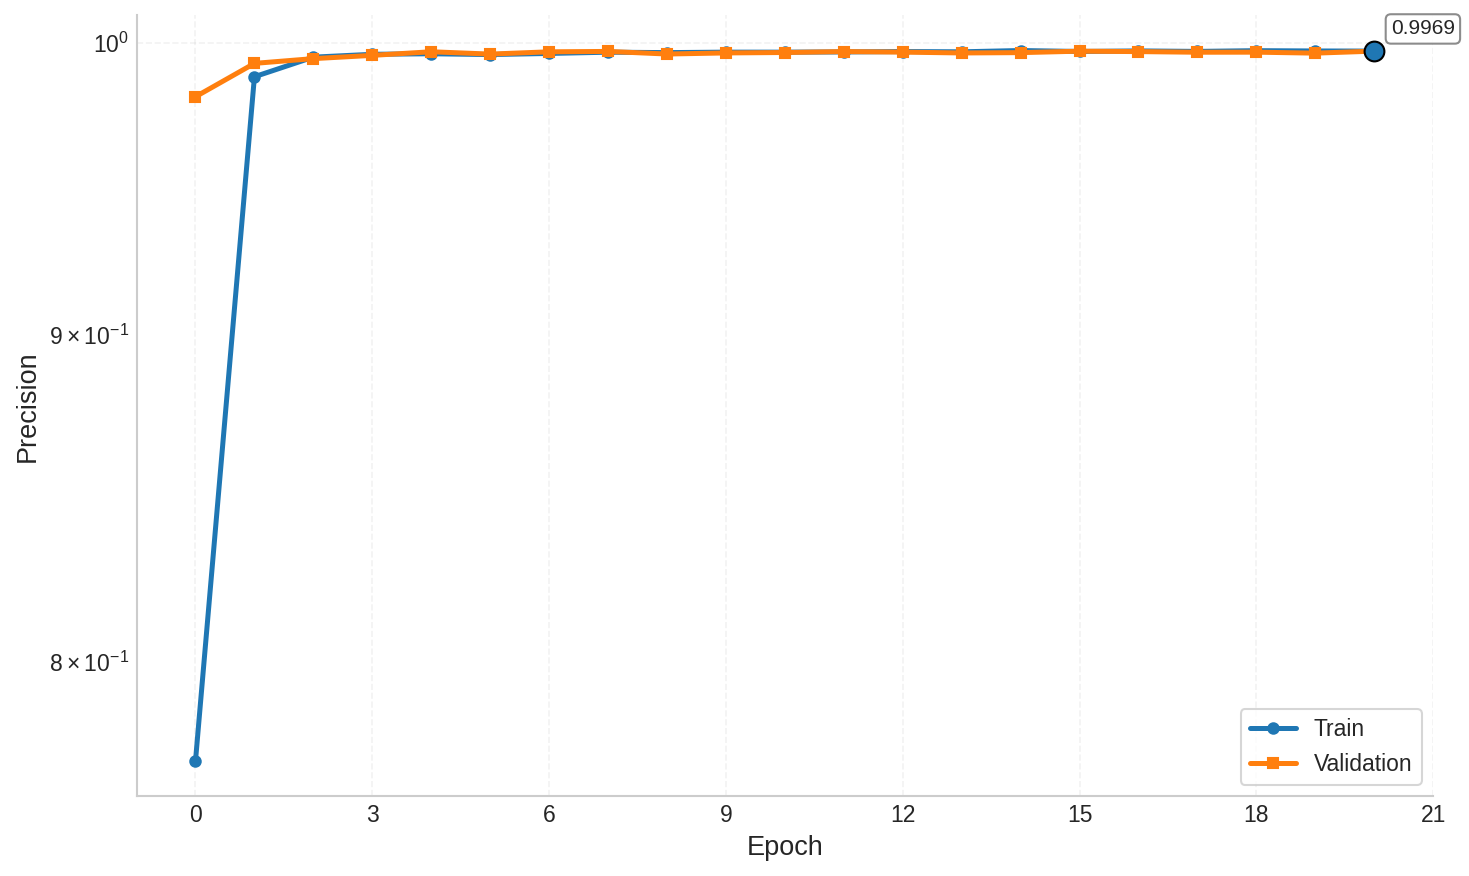

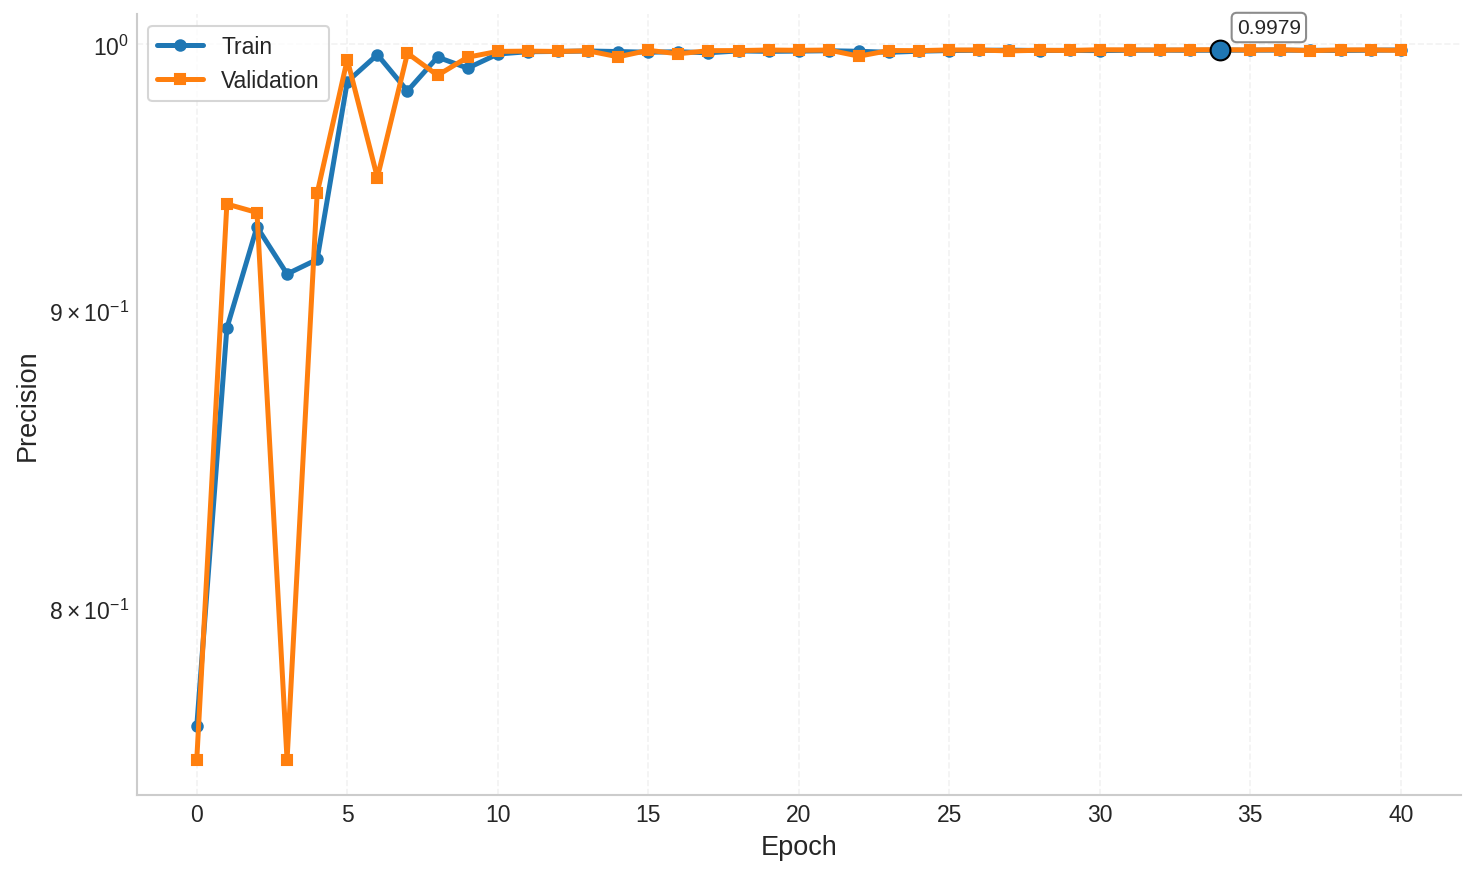

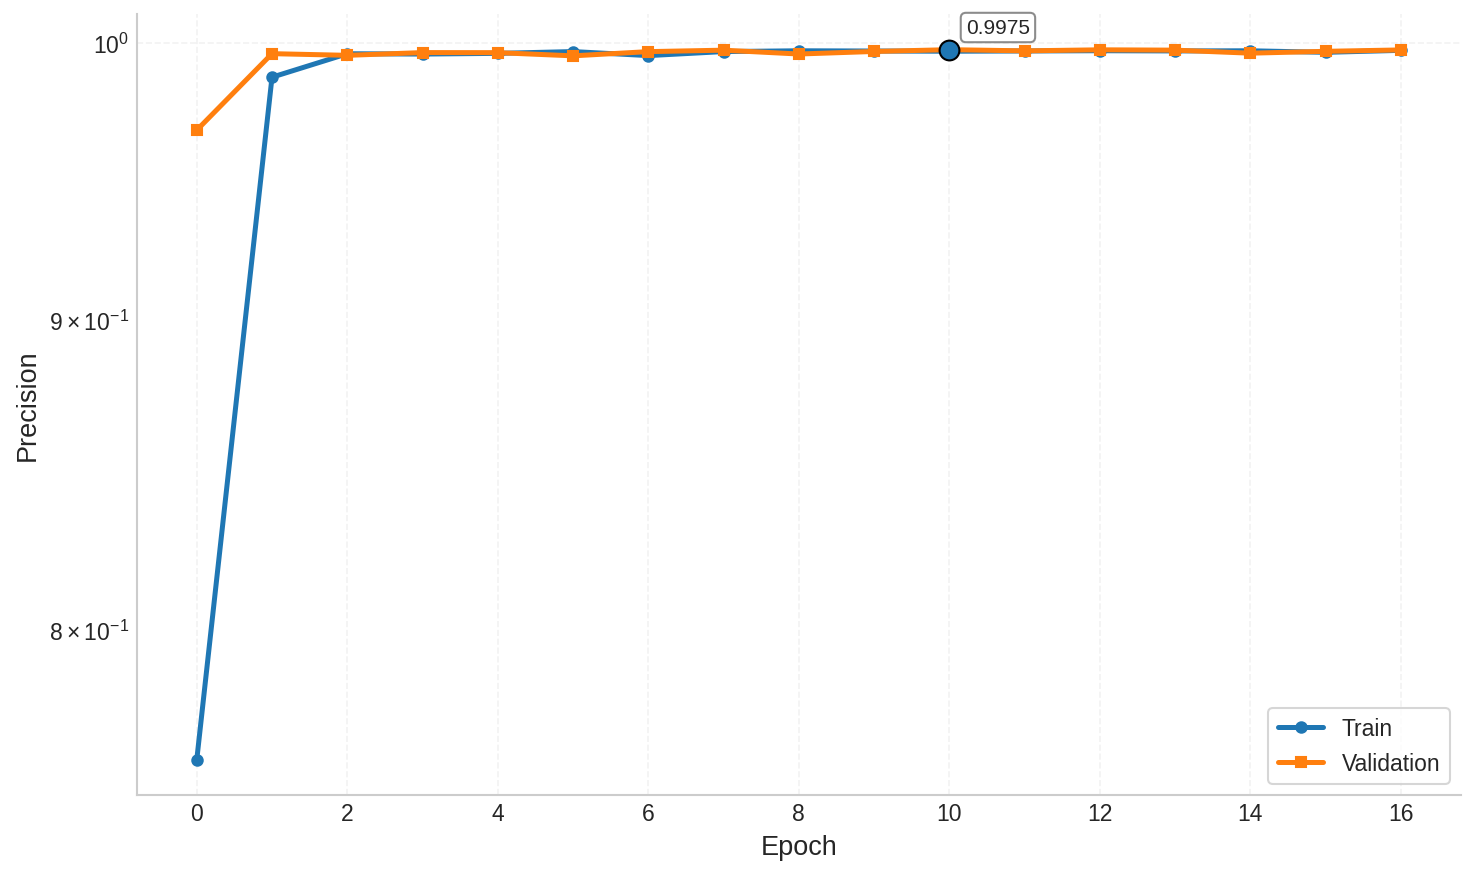

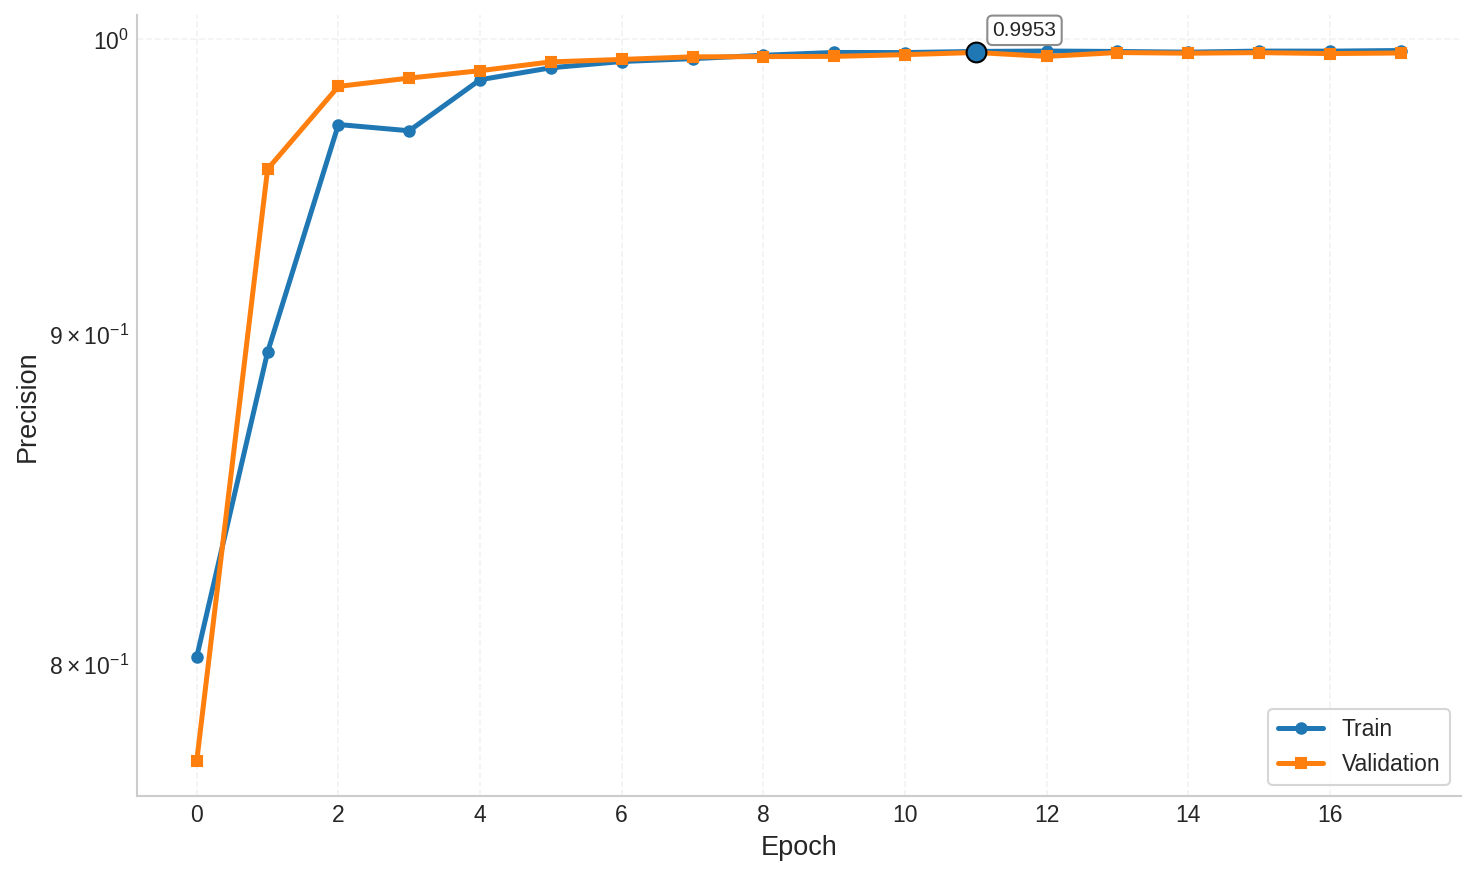

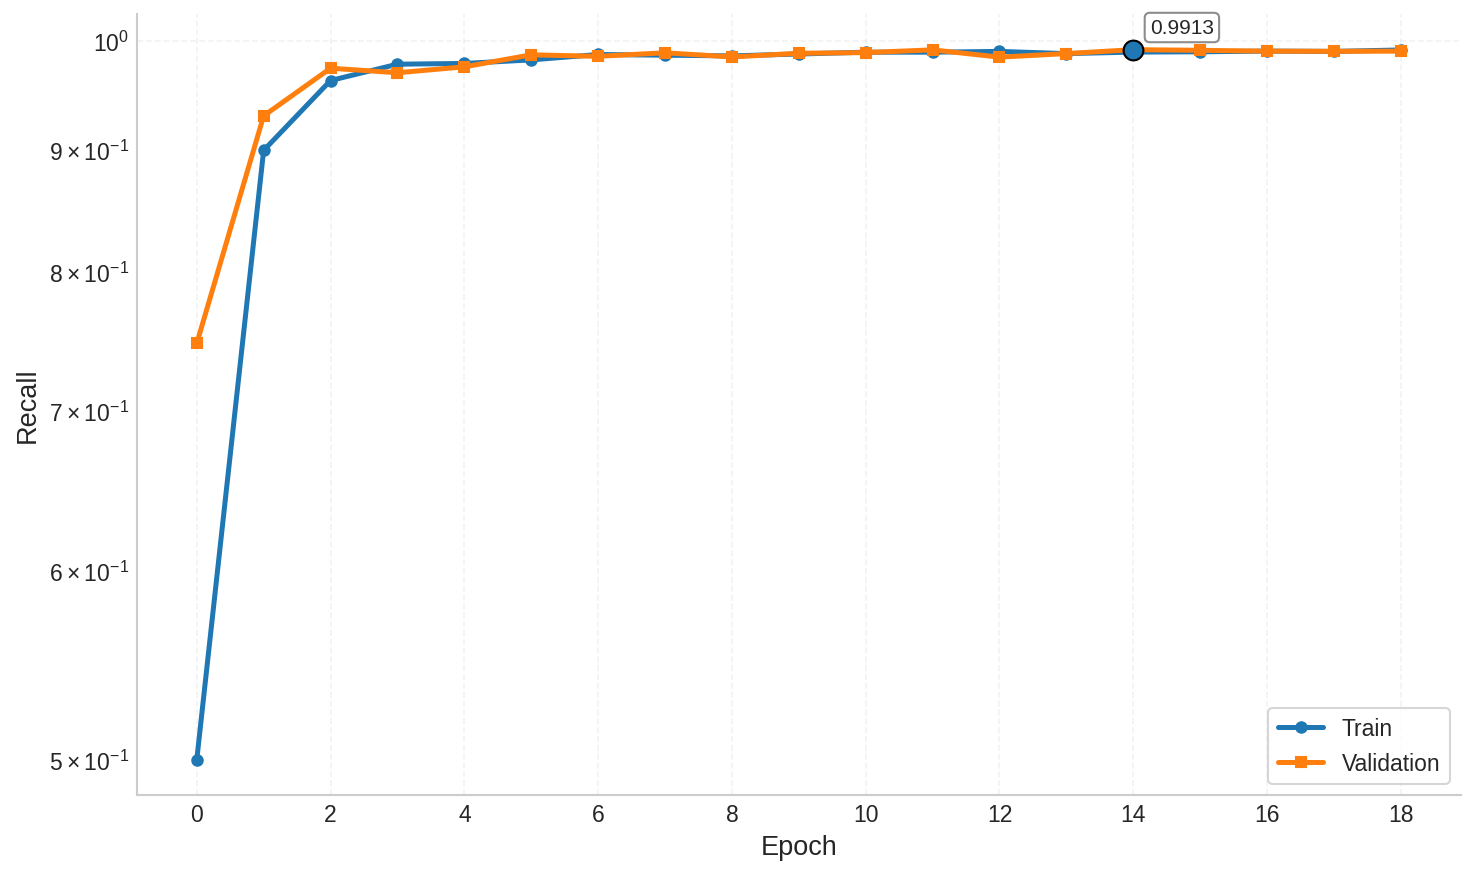

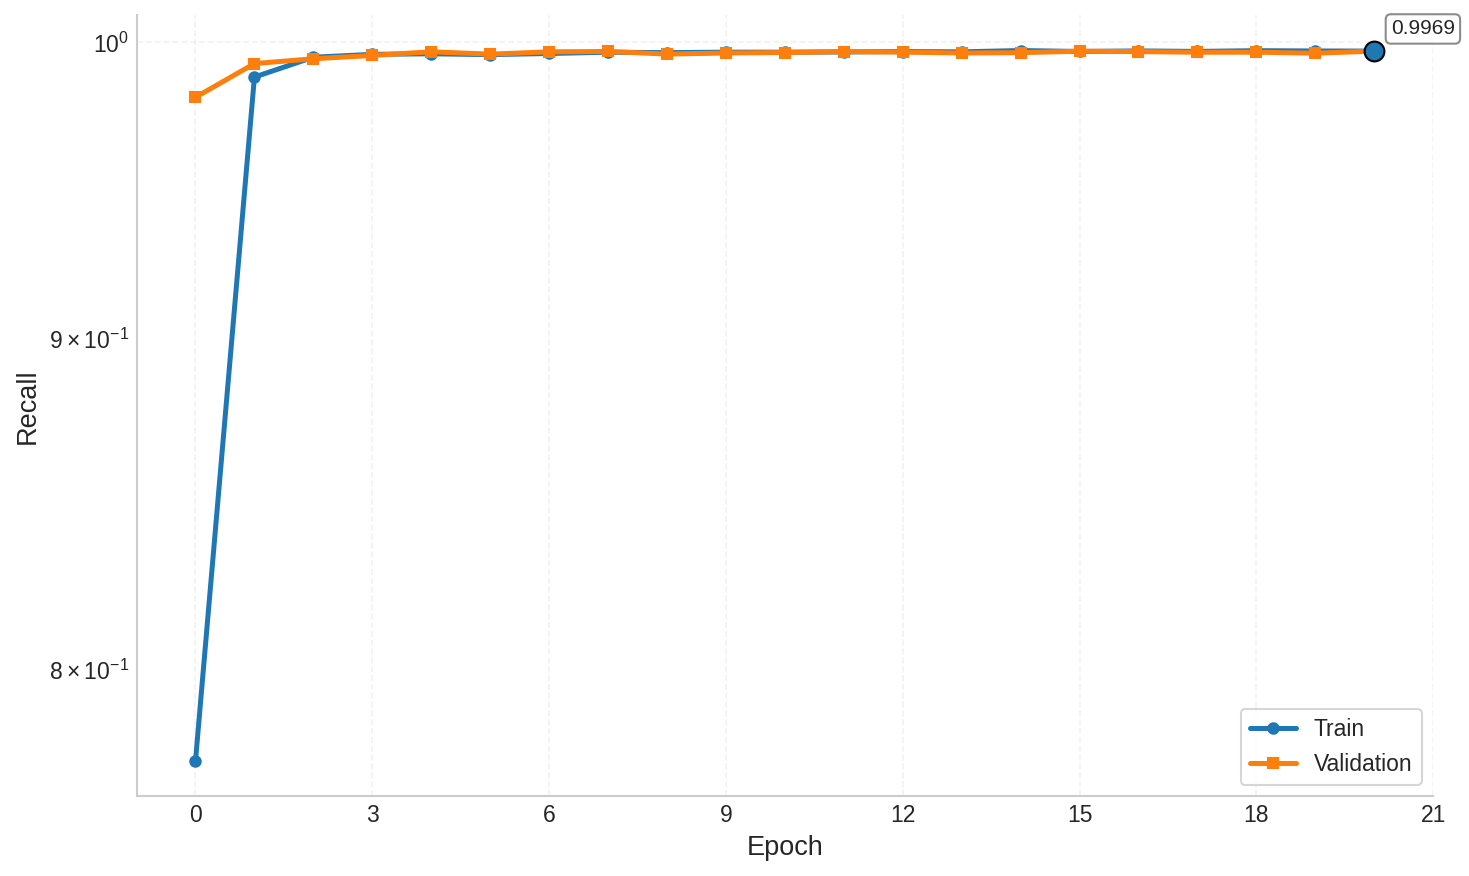

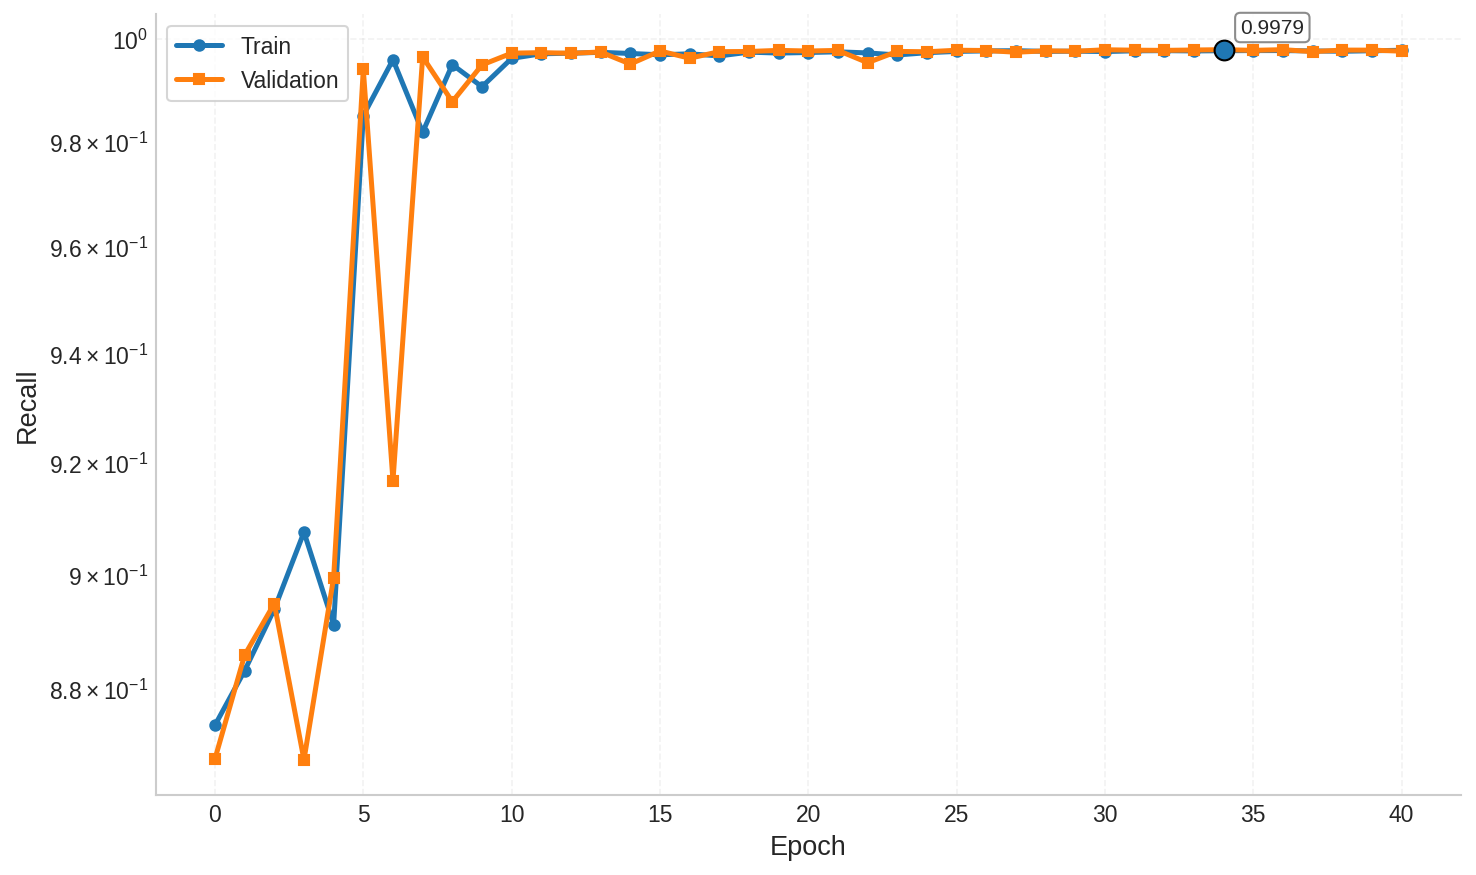

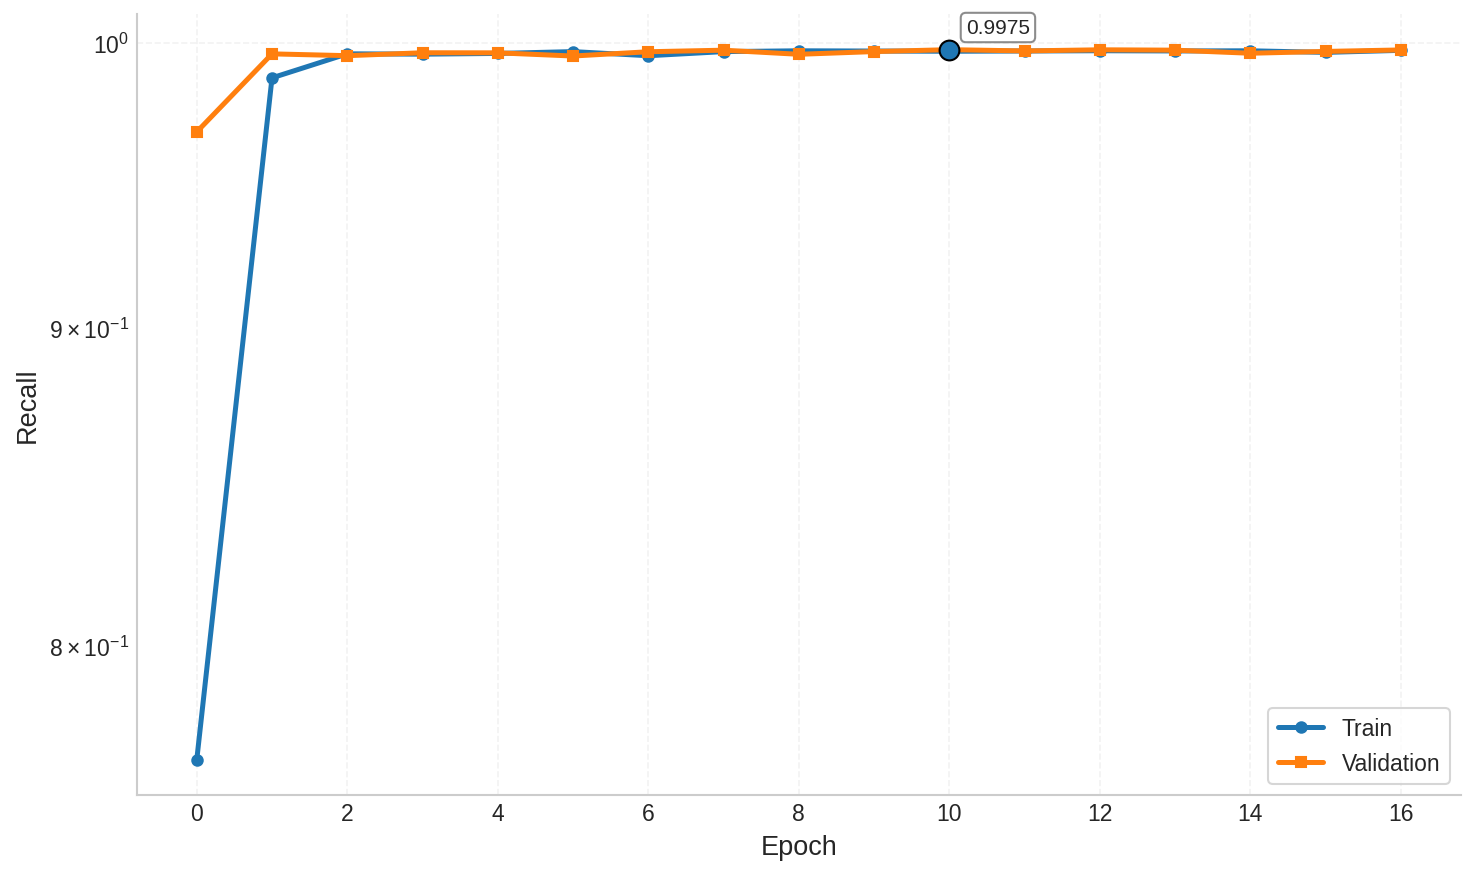

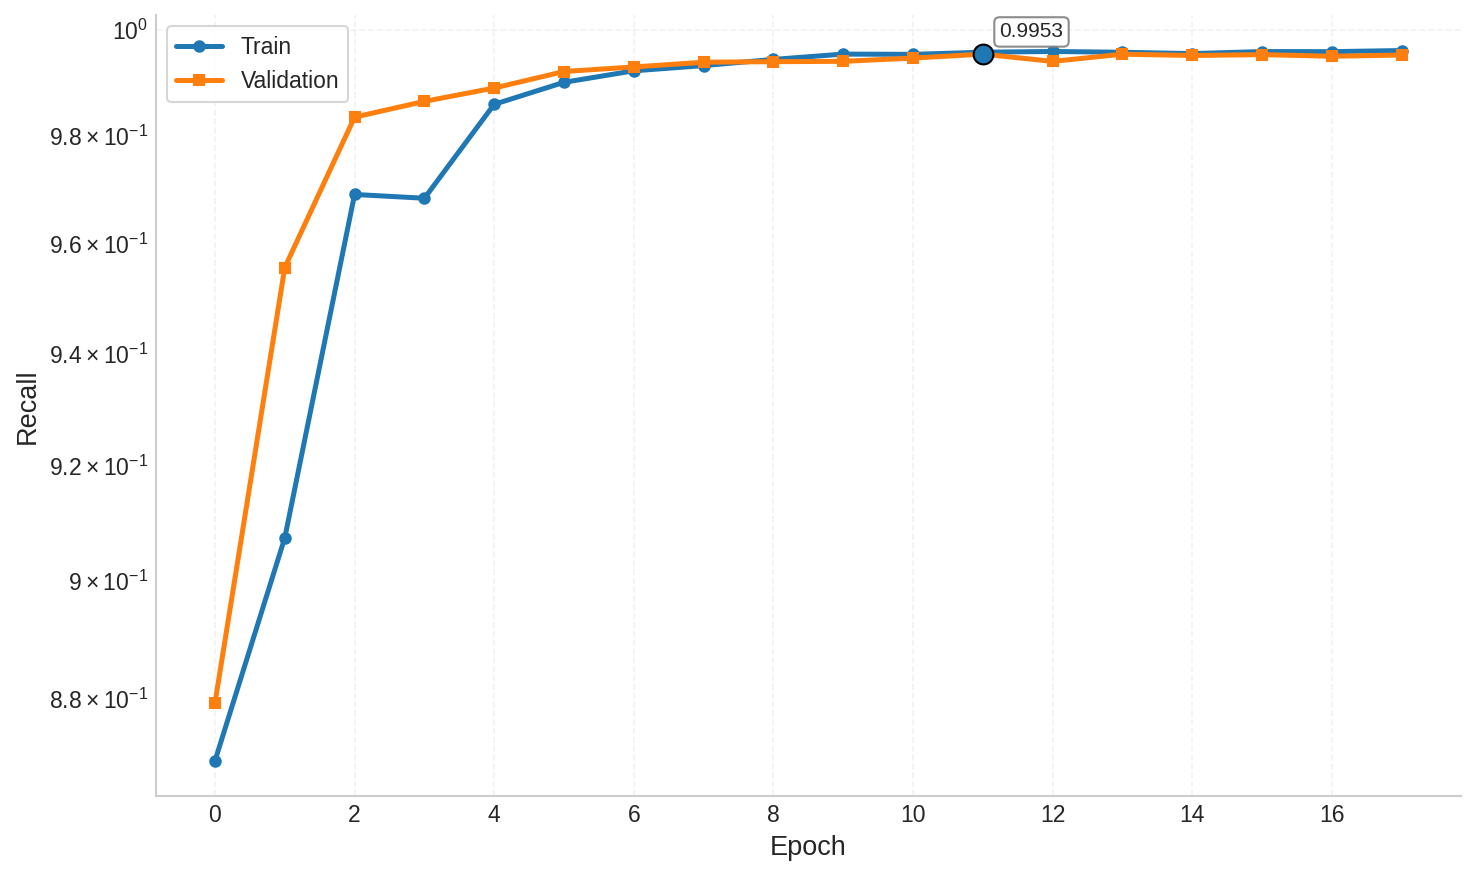

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# =========================
# Settings
# =========================
base_dir = "results/activity_recognition/machine_and_movement"
use_log_y = False   # True -> logarithmic y-axis
show_plots = True   # True -> display plots
save_plots = True   # True -> save plots as PDF in same folder

# =========================
# Plot style
# =========================
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.4,
    "lines.markersize": 5,
})

def pretty_metric_name(metric_name: str) -> str:
    name = metric_name.replace("train_", "").replace("val_", "")
    name = name.replace("_", " ").title()
    name = name.replace("Iou", "IoU")
    return name

def safe_name(text: str) -> str:
    return str(text).replace("/", "_").replace("\\", "_").replace(" ", "_")

# =========================
# Read all CSV files
# =========================
csv_files = sorted(glob.glob(os.path.join(base_dir, "*.csv")))

for file_path in csv_files:
    file_name = os.path.basename(file_path).replace(".csv", "")
    metric_parts = file_name.split("-")

    if len(metric_parts) != 2:
        print(f"Skipping {file_name}: unexpected filename format")
        continue

    train_metric, val_metric = metric_parts

    # Read CSV
    df = pd.read_csv(file_path)

    # Convert numeric columns
    for col in ["step", "timestamp", "value"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Clean data
    required_cols = ["step", "value", "metric", "Run"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Skipping {file_name}: missing columns {missing_cols}")
        continue

    df = df.drop_duplicates()
    df = df.dropna(subset=["step", "value", "metric", "Run"])
    df = df[df["metric"].isin([train_metric, val_metric])]
    df = df.sort_values(["Run", "metric", "step"])

    runs = df["Run"].unique()
    metric_label = pretty_metric_name(train_metric)

    if len(runs) == 0:
        print(f"No valid runs found in {file_name}")
        continue

    for run_name in runs:
        run_df = df[df["Run"] == run_name]

        train_df = run_df[run_df["metric"] == train_metric]
        val_df = run_df[run_df["metric"] == val_metric]

        fig, ax = plt.subplots()

        # Plot train
        ax.plot(
            train_df["step"],
            train_df["value"],
            marker="o",
            label="Train"
        )

        # Plot validation
        ax.plot(
            val_df["step"],
            val_df["value"],
            marker="s",
            label="Validation"
        )

        # Best validation point
        if not val_df.empty:
            if "loss" in metric_label.lower():
                best_idx = val_df["value"].idxmin()
            else:
                best_idx = val_df["value"].idxmax()

            best_row = val_df.loc[best_idx]

            ax.scatter(
                best_row["step"],
                best_row["value"],
                s=90,
                edgecolor="black",
                linewidth=1.0,
                zorder=5
            )

            ax.annotate(
                f"{best_row['value']:.4f}",
                (best_row["step"], best_row["value"]),
                textcoords="offset points",
                xytext=(8, 8),
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    fc="white",
                    ec="gray",
                    alpha=0.9
                )
            )

        # Axis labels
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_label)

        # Integer ticks for epochs
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # Optional log scale on y-axis
        if use_log_y:
            positive_values = run_df["value"][run_df["value"] > 0]
            if not positive_values.empty:
                ax.set_yscale("log")
            else:
                print(f"Skipping log scale for {file_name} - {run_name}: non-positive values found")

        # Better y-limits for normal scale
        if not use_log_y and not run_df.empty:
            y_min = run_df["value"].min()
            y_max = run_df["value"].max()
            if y_max > y_min:
                margin = (y_max - y_min) * 0.08
                ax.set_ylim(y_min - margin, y_max + margin)

        ax.legend(frameon=True)
        plt.tight_layout()

        # Save PDF in same folder
        if save_plots:
            output_name = f"{file_name}_{safe_name(run_name)}.pdf"
            output_path = os.path.join(base_dir, output_name)
            plt.savefig(output_path, format="pdf", bbox_inches="tight")

        if show_plots:
            plt.show()
        else:
            plt.close(fig)